# Extension Memo: Network Fragility and Redundancy Under Sea-Level Rise
### South Florida Tri-County Study Area (Broward, Miami-Dade, Palm Beach)

**Status:** Working draft — not for citation

---

This notebook builds a cohesive analysis dataset and preliminary findings for an extension of
Best et al. (2023). Rather than focusing only on *binary isolation* (is there any dry path?),
this project measures *network fragility* and *redundancy* under sea-level rise:

- **Isolated** — no dry route to services exists
- **Fragile** — connected, but only via a single dry path (edge-disjoint paths = 1)
- **Redundant** — connected with 2+ edge-disjoint dry paths

The central analytic argument: many blocks lose network redundancy — becoming fragile —
**before** they become fully isolated. Standard binary-isolation metrics miss this earlier
deterioration in network resilience.

## Motivation

Standard access-under-SLR analyses define a binary outcome: is the block reachable via some
dry path? This treats "barely connected through a single corridor" the same as "connected via
multiple independent routes." Network redundancy is a core resilience concept — a fragile
connection (one dry path) is qualitatively different from a redundant one, because a single
additional inundated edge can sever it completely.

### Conceptual Status Hierarchy

```
Redundant  →  Fragile  →  Isolated  →  Inundated
(2+ paths)   (1 path)    (0 paths)   (origin submerged)
```

As SLR increases, blocks may transition through this hierarchy. `Redundant → Fragile` is an
analytically distinct event — a loss of resilience — that binary isolation measures cannot detect.

### On Renaming `detour_ratio` to `path_inflation_ratio`

The raw data contain `detour_ratio = dry_shortest_path / baseline_shortest_path`. We rename
this to **`path_inflation_ratio`** in the analysis, with **"dry-path inflation ratio"** as the
preferred narrative label.

**Why not "detour ratio"?** The term implies a guaranteed commute-time effect. The network is
undirected, uses OSM segments intersected with NOAA inundation polygons, and does not model
traffic or turn restrictions. "Dry-path inflation ratio" is more precise: it measures how much
longer the *modeled* dry path is under the assumption that all inundated segments are
impassable. The raw `detour_ratio` column is preserved for traceability.

## 1. Setup and Project Paths

Import packages, configure paths, create output directories.

In [70]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

from pathlib import Path
import json
import urllib.request
import urllib.error

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

try:
    import seaborn as sns
    HAS_SEABORN = True
    sns.set_theme(style="whitegrid", font_scale=0.95)
except ImportError:
    HAS_SEABORN = False
    print("NOTE: seaborn not installed — using matplotlib defaults.")

try:
    import statsmodels.formula.api as smf
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
    print("WARNING: statsmodels not installed — regression section will be skipped.")

print("Imports complete.")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", "{:.4f}".format)

Imports complete.


In [71]:
# ---------------------------------------------------------------------------
# Project paths
# ---------------------------------------------------------------------------
# This notebook is expected to live in scripts/ within the project root.
# If your working directory differs, update PROJECT_ROOT below.
NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent

# Precomputed access flag run
RUN_DATE = "2026-04-03_run"
RUN_DIR  = PROJECT_ROOT / "data" / "processed" / "access" / "edited" / RUN_DATE
DIAG_DIR = RUN_DIR / "diagnostics"

# Analysis outputs
ANALYSIS_DIR = PROJECT_ROOT / "data" / "processed" / "analysis"
FIGURES_DIR  = PROJECT_ROOT / "outputs" / "figures"
TABLES_DIR   = PROJECT_ROOT / "outputs" / "tables"

for d in [ANALYSIS_DIR, FIGURES_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Census API
CENSUS_API_KEY = "ff5d487d0a2a22c658bf319ba136c27db32aa0be"
CENSUS_YEAR    = "2022"

# Study area
STUDY_STATE    = "12"   # Florida
STUDY_COUNTIES = {"011": "Broward", "086": "Miami-Dade", "099": "Palm Beach"}
SLR_LEVELS     = list(range(1, 7))

# Dtypes for reading raw files — preserves leading zeros in GEOIDs
RESULT_DTYPE = {
    "block_geoid":                    "string",
    "block_group_geoid":              "string",
    "tract_geoid":                    "string",
    "block":                          "string",
    "county_fips":                    "string",
    "county_name":                    "string",
    "slr_layer_name":                 "string",
    "nearest_reachable_service_type": "string",
    "nearest_reachable_service_id":   "string",
    "baseline_status":                "string",
    "scenario_status":                "string",
}

# Visualization constants
STATUS_ORDER  = ["inundated", "isolated", "fragile", "redundant"]
STATUS_COLORS = {
    "inundated": "#1f78b4",
    "isolated":  "#d7301f",
    "fragile":   "#fdae61",
    "redundant": "#bdbdbd",
}
COUNTY_COLORS = {
    "Broward":    "#4daf4a",
    "Miami-Dade": "#984ea3",
    "Palm Beach": "#ff7f00",
}

print(f"Project root : {PROJECT_ROOT}")
print(f"Run directory: {RUN_DIR}")
assert RUN_DIR.exists(), f"Run directory not found: {RUN_DIR}"
print("Paths OK. Output directories ready.")

Project root : C:\Users\Vivek\Dropbox\repos\slr_fl_fragile_access
Run directory: C:\Users\Vivek\Dropbox\repos\slr_fl_fragile_access\data\processed\access\edited\2026-04-03_run
Paths OK. Output directories ready.


## 2. Inspect Scenario Files

Find all `block_access_flags_long*.csv` files, inventory their contents, and verify that the
baseline rows (`slr_ft == 0`) are consistent across files before extracting one canonical copy.

Each file contains:
- **Baseline rows** (`slr_ft == 0`) — identical across all 6 files (to be verified below)
- **Scenario rows** (`slr_ft == X`) — unique to each file

In [72]:
# Find scenario files
csv_files = sorted(
    p for p in RUN_DIR.glob("block_access_flags_long*.csv")
    if "qa_sample" not in p.stem
)
print(f"Found {len(csv_files)} scenario file(s):")
for f in csv_files:
    print(f"  {f.name}")

# Build file inventory
inventory_records = []
for path in csv_files:
    slim = pd.read_csv(path, usecols=["slr_ft"], dtype={"slr_ft": "Int64"})
    counts = slim["slr_ft"].value_counts().sort_index()
    inventory_records.append({
        "file_name":         path.name,
        "total_rows":        len(slim),
        "slr_ft_values":     ", ".join(str(int(x)) for x in counts.index.tolist()),
        "n_baseline_rows":   int(counts.get(0, 0)),
        "n_scenario_rows":   int(slim["slr_ft"].ne(0).sum()),
    })

inventory_df = pd.DataFrame(inventory_records)
display(inventory_df)

Found 6 scenario file(s):
  block_access_flags_longslr1.csv
  block_access_flags_longslr2.csv
  block_access_flags_longslr3.csv
  block_access_flags_longslr4.csv
  block_access_flags_longslr5.csv
  block_access_flags_longslr6.csv


,file_name,total_rows,slr_ft_values,n_baseline_rows,n_scenario_rows
0,block_access_flags_longslr1.csv,141390,"0, 1",70695,70695
1,block_access_flags_longslr2.csv,141390,"0, 2",70695,70695
2,block_access_flags_longslr3.csv,141390,"0, 3",70695,70695
3,block_access_flags_longslr4.csv,141390,"0, 4",70695,70695
4,block_access_flags_longslr5.csv,141390,"0, 5",70695,70695
5,block_access_flags_longslr6.csv,141390,"0, 6",70695,70695


In [73]:
# ---------------------------------------------------------------------------
# Verify baseline consistency: are the slr_ft==0 rows identical across files?
# ---------------------------------------------------------------------------
BASELINE_CHECK_COLS = [
    "block_geoid", "block_centroid_inundated", "block_centroid_isolated",
    "block_centroid_redundant", "block_centroid_fragile",
    "n_reachable_services", "max_edge_disjoint_paths_any_service",
    "baseline_status", "scenario_status",
]

baseline_frames = {}
for path in csv_files:
    df = pd.read_csv(path, usecols=["slr_ft"] + BASELINE_CHECK_COLS,
                     dtype={**RESULT_DTYPE, "slr_ft": "Int64"})
    df["slr_ft"] = df["slr_ft"].astype(int)
    bl = (df.loc[df["slr_ft"] == 0, BASELINE_CHECK_COLS]
           .sort_values("block_geoid")
           .reset_index(drop=True))
    baseline_frames[path.name] = bl
    print(f"  {path.name}: {len(bl):,} baseline rows")

ref_name = list(baseline_frames.keys())[0]
ref_bl   = baseline_frames[ref_name]

all_equal = True
for name, bl in baseline_frames.items():
    if name == ref_name:
        continue
    try:
        pd.testing.assert_frame_equal(ref_bl, bl, check_dtype=False)
    except AssertionError as e:
        print(f"WARNING — {name} baseline differs from {ref_name}: {e}")
        all_equal = False

if all_equal:
    print(f"\nBaseline consistency check PASSED across all {len(baseline_frames)} files.")
    print(f"Canonical baseline size: {len(ref_bl):,} blocks")
else:
    print("\nWARNING: Baseline inconsistency detected. Investigate before proceeding.")

  block_access_flags_longslr1.csv: 70,695 baseline rows
  block_access_flags_longslr2.csv: 70,695 baseline rows
  block_access_flags_longslr3.csv: 70,695 baseline rows
  block_access_flags_longslr4.csv: 70,695 baseline rows
  block_access_flags_longslr5.csv: 70,695 baseline rows
  block_access_flags_longslr6.csv: 70,695 baseline rows

Baseline consistency check PASSED across all 6 files.
Canonical baseline size: 70,695 blocks


## 3. Build Canonical Block-Level Long Dataset

**Design:**
1. Extract baseline (`slr_ft == 0`) from exactly one file (verified identical across all files above).
2. Load scenario-only rows (`slr_ft != 0`) from each file and stack.
3. Assert uniqueness on `(block_geoid, slr_ft)` before proceeding.
4. Standardize GEOID columns as zero-padded strings.
5. Create derived analysis variables.

### Key Variable Notes

**`path_inflation_ratio`** — renamed from raw `detour_ratio`.
- Definition: `dry_shortest_path_distance_m / baseline_shortest_path_distance_m`
- `= 1.0` if the dry route is unchanged; `> 1.0` if a longer route is needed due to inundated segments
- `NaN` if the block is isolated or inundated (no dry path exists — ratio is undefined)
- The raw `detour_ratio` column is preserved for traceability.

> **TODO**: The upstream code caps `max_edge_disjoint_paths_any_service` at 2
> (`MAX_EDGE_DISJOINT_PATHS_CAP = 2`). This means the model cannot distinguish 2-path from
> 3+ path redundancy. The fragile/redundant categories are therefore coarser than they appear.

In [74]:
# Extract one canonical baseline (slr_ft == 0) from the first file
ref_path = csv_files[0]
print(f"Loading baseline from: {ref_path.name}")

full_ref = pd.read_csv(ref_path, dtype=RESULT_DTYPE, low_memory=False)
full_ref["slr_ft"] = full_ref["slr_ft"].astype(int)

baseline_df = (full_ref.loc[full_ref["slr_ft"] == 0]
               .copy()
               .sort_values("block_geoid")
               .reset_index(drop=True))

assert baseline_df["block_geoid"].is_unique, "Duplicate block_geoid in baseline."
assert set(baseline_df["slr_ft"].unique()) == {0}, "Unexpected slr_ft in baseline."

print(f"Canonical baseline: {len(baseline_df):,} unique blocks")
del full_ref

Loading baseline from: block_access_flags_longslr1.csv
Canonical baseline: 70,695 unique blocks


In [75]:
# Load scenario rows (slr_ft != 0) from each file and stack
scenario_frames = []
for path in csv_files:
    df = pd.read_csv(path, dtype=RESULT_DTYPE, low_memory=False)
    df["slr_ft"] = df["slr_ft"].astype(int)
    scen = df.loc[df["slr_ft"] != 0].copy()
    scenario_frames.append(scen)
    print(f"  {path.name}: {len(scen):,} scenario rows")
    del df

scenarios_df = pd.concat(scenario_frames, ignore_index=True)
del scenario_frames

dupes = scenarios_df.duplicated(subset=["block_geoid", "slr_ft"])
if dupes.sum() > 0:
    print(f"WARNING: {dupes.sum()} duplicate (block_geoid, slr_ft) rows — keeping first.")
    scenarios_df = scenarios_df.loc[~dupes].copy()
else:
    print("No duplicate (block_geoid, slr_ft) rows. Good.")

scenarios_df = scenarios_df.sort_values(["slr_ft", "block_geoid"]).reset_index(drop=True)
print(f"\nScenario rows: {len(scenarios_df):,}")
print(f"SLR levels: {sorted(scenarios_df['slr_ft'].unique().tolist())}")
print(f"Unique blocks in scenarios: {scenarios_df['block_geoid'].nunique():,}")

  block_access_flags_longslr1.csv: 70,695 scenario rows
  block_access_flags_longslr2.csv: 70,695 scenario rows
  block_access_flags_longslr3.csv: 70,695 scenario rows
  block_access_flags_longslr4.csv: 70,695 scenario rows
  block_access_flags_longslr5.csv: 70,695 scenario rows
  block_access_flags_longslr6.csv: 70,695 scenario rows
No duplicate (block_geoid, slr_ft) rows. Good.

Scenario rows: 424,170
SLR levels: [1, 2, 3, 4, 5, 6]
Unique blocks in scenarios: 70,695


In [76]:
# Stack baseline + scenarios into one canonical long dataset
long_df = pd.concat([baseline_df, scenarios_df], ignore_index=True)
long_df = long_df.sort_values(["slr_ft", "block_geoid"]).reset_index(drop=True)

# Standardize GEOIDs
for col, width in [("block_geoid", 15), ("block_group_geoid", 12),
                   ("tract_geoid", 11), ("county_fips", 3)]:
    if col in long_df.columns:
        long_df[col] = long_df[col].astype(str).str.zfill(width)

# Row count checks
n_blocks   = baseline_df["block_geoid"].nunique()
n_expected = n_blocks * (1 + len(SLR_LEVELS))
n_actual   = len(long_df)
n_keys     = long_df.drop_duplicates(subset=["block_geoid", "slr_ft"]).shape[0]

print(f"Long dataset: {n_actual:,} rows")
print(f"  Unique (block_geoid, slr_ft) pairs: {n_keys:,}")
print(f"  Expected: {n_expected:,} ({n_blocks:,} blocks x {1 + len(SLR_LEVELS)} SLR levels)")

if n_actual != n_keys:
    print(f"WARNING: {n_actual - n_keys} duplicate rows detected.")
if n_actual != n_expected:
    print(f"WARNING: Row count {n_actual} differs from expected {n_expected}.")
else:
    print("Row count checks passed.")

display(long_df[["block_geoid", "block_group_geoid", "county_name",
                  "slr_ft", "scenario_status", "baseline_status"]].head(6))

Long dataset: 494,865 rows
  Unique (block_geoid, slr_ft) pairs: 494,865
  Expected: 494,865 (70,695 blocks x 7 SLR levels)
Row count checks passed.


,block_geoid,block_group_geoid,county_name,slr_ft,scenario_status,baseline_status
0,120110101021000,120110101021,Broward,0,redundant,redundant
1,120110101021001,120110101021,Broward,0,redundant,redundant
2,120110101021002,120110101021,Broward,0,inundated,inundated
3,120110101021003,120110101021,Broward,0,fragile,fragile
4,120110101021004,120110101021,Broward,0,redundant,redundant
5,120110101021005,120110101021,Broward,0,fragile,fragile


In [77]:
# ---------------------------------------------------------------------------
# Derived analysis variables
# ---------------------------------------------------------------------------

# 1. Ordered 4-category status
long_df["status_4cat"] = pd.Categorical(
    long_df["scenario_status"],
    categories=["inundated", "isolated", "fragile", "redundant"],
    ordered=True,
)

# 2. Fragile-or-worse: fragile | isolated | inundated
long_df["fragile_or_worse"] = (
    long_df["scenario_status"].isin(["fragile", "isolated", "inundated"])
).astype("Int8")

# 3. Any loss of redundancy: baseline-redundant → any worse outcome
long_df["any_loss_of_redundancy"] = (
    long_df["baseline_block_centroid_redundant"].eq(1) &
    long_df["scenario_status"].isin(["fragile", "isolated", "inundated"])
).astype("Int8")

# 4. Granular transition indicators
long_df["baseline_redundant_to_fragile"] = (
    long_df["baseline_block_centroid_redundant"].eq(1) & long_df["block_centroid_fragile"].eq(1)
).astype("Int8")
long_df["baseline_redundant_to_isolated"] = (
    long_df["baseline_block_centroid_redundant"].eq(1) & long_df["block_centroid_isolated"].eq(1)
).astype("Int8")
long_df["baseline_redundant_to_inundated"] = (
    long_df["baseline_block_centroid_redundant"].eq(1) & long_df["block_centroid_inundated"].eq(1)
).astype("Int8")
long_df["baseline_fragile_persisted"]    = long_df["persistent_fragile"].astype("Int8")
long_df["baseline_fragile_to_isolated"]  = (
    long_df["baseline_block_centroid_fragile"].eq(1) & long_df["block_centroid_isolated"].eq(1)
).astype("Int8")
long_df["baseline_fragile_to_inundated"] = (
    long_df["baseline_block_centroid_fragile"].eq(1) & long_df["block_centroid_inundated"].eq(1)
).astype("Int8")
long_df["baseline_isolated_to_inundated"] = (
    long_df["baseline_block_centroid_isolated"].eq(1) &
    long_df["block_centroid_inundated"].eq(1)
).astype("Int8")

# 5. Convenience aliases
long_df["became_fragile"]   = long_df["new_fragile_due_to_slr"].astype("Int8")
long_df["became_isolated"]  = long_df["new_isolated_due_to_slr"].astype("Int8")
long_df["became_inundated"] = long_df["new_inundated_due_to_slr"].astype("Int8")

# 6. Path inflation ratio — renamed from detour_ratio
# Raw detour_ratio is preserved. path_inflation_ratio is set to NaN for
# isolated/inundated blocks where no dry path exists.
long_df["path_inflation_ratio"] = pd.to_numeric(long_df["detour_ratio"], errors="coerce")

iso_or_inh = (long_df["block_centroid_isolated"].eq(1) | long_df["block_centroid_inundated"].eq(1))
long_df.loc[iso_or_inh, "path_inflation_ratio"] = np.nan
long_df["path_inflation_ratio"] = long_df["path_inflation_ratio"].replace([np.inf, -np.inf], np.nan)

# Sanity: connected blocks should have ratio >= 1.0
conn_mask  = long_df["path_inflation_ratio"].notna()
below_one  = (long_df.loc[conn_mask, "path_inflation_ratio"] < 0.99).sum()
if below_one > 0:
    print(f"WARNING: {below_one} connected blocks have path_inflation_ratio < 1.0 — investigate.")
else:
    print(f"path_inflation_ratio OK: {conn_mask.sum():,} connected, "
          f"{long_df['path_inflation_ratio'].isna().sum():,} NaN (isolated/inundated).")

print("Derived variables created.")
display(long_df[["block_geoid", "slr_ft", "scenario_status", "fragile_or_worse",
                  "any_loss_of_redundancy", "became_fragile", "path_inflation_ratio"]].head(8))

path_inflation_ratio OK: 433,518 connected, 61,347 NaN (isolated/inundated).
Derived variables created.


,block_geoid,slr_ft,scenario_status,fragile_or_worse,any_loss_of_redundancy,became_fragile,path_inflation_ratio
0,120110101021000,0,redundant,0,0,0,1.0000
1,120110101021001,0,redundant,0,0,0,1.0000
2,120110101021002,0,inundated,1,0,0,NaN
3,120110101021003,0,fragile,1,0,0,1.0000
4,120110101021004,0,redundant,0,0,0,1.0000
5,120110101021005,0,fragile,1,0,0,1.0000
6,120110101021006,0,redundant,0,0,0,1.0000
7,120110101021007,0,redundant,0,0,0,1.0000


## 4. Validation and Diagnostics

Compare our canonical dataset against the precomputed diagnostic files in `diagnostics/`.
Any discrepancies are flagged explicitly — nothing is silently ignored.

In [78]:
# Reproduce baseline_vs_scenario_crosstab and compare to precomputed file
positive = long_df.loc[long_df["slr_ft"] != 0].copy()

crosstab_own = (
    positive
    .groupby(["slr_ft", "baseline_status", "scenario_status"], as_index=False)
    .agg(n_blocks_own=("block_geoid", "size"))
    .sort_values(["slr_ft", "baseline_status", "scenario_status"])
    .reset_index(drop=True)
)

crosstab_ref = (
    pd.read_csv(DIAG_DIR / "baseline_vs_scenario_crosstab.csv")
    .sort_values(["slr_ft", "baseline_status", "scenario_status"])
    .reset_index(drop=True)
)

comp = crosstab_ref.merge(
    crosstab_own,
    on=["slr_ft", "baseline_status", "scenario_status"],
    how="outer",
    validate="one_to_one",
).fillna(0)
comp["diff"] = comp["n_blocks"] - comp["n_blocks_own"]

if comp["diff"].abs().max() == 0:
    print("VALIDATION PASSED: crosstab matches precomputed diagnostic exactly.")
else:
    print(f"DISCREPANCY: max |diff| = {comp['diff'].abs().max()}")
    display(comp.loc[comp["diff"].ne(0)])

print("\nBaseline→Scenario crosstab from canonical dataset:")
display(crosstab_own)

VALIDATION PASSED: crosstab matches precomputed diagnostic exactly.

Baseline→Scenario crosstab from canonical dataset:


,slr_ft,baseline_status,scenario_status,n_blocks_own
0,1,fragile,fragile,17399
1,1,fragile,inundated,57
2,1,fragile,isolated,2
3,1,inundated,inundated,1095
4,1,isolated,inundated,19
5,1,isolated,isolated,2451
6,1,redundant,fragile,15
7,1,redundant,inundated,31
8,1,redundant,isolated,8
9,1,redundant,redundant,49618


In [79]:
# Reproduce transition_summary_by_slr and cross-check
transition_own = (
    positive
    .groupby("slr_ft", as_index=False)
    .agg(
        n_blocks                          = ("block_geoid",                   "size"),
        n_new_fragile                     = ("new_fragile_due_to_slr",        "sum"),
        n_new_isolated                    = ("new_isolated_due_to_slr",       "sum"),
        n_new_inundated                   = ("new_inundated_due_to_slr",      "sum"),
        n_baseline_redundant_to_fragile   = ("baseline_redundant_to_fragile", "sum"),
        n_baseline_redundant_to_isolated  = ("baseline_redundant_to_isolated","sum"),
        n_baseline_redundant_to_inundated = ("baseline_redundant_to_inundated","sum"),
        n_any_loss_of_redundancy          = ("any_loss_of_redundancy",        "sum")
    )
    .sort_values("slr_ft")
    .reset_index(drop=True)
)

transition_ref = pd.read_csv(DIAG_DIR / "transition_summary_by_slr.csv")

# Cross-check key columns
check_pairs = [
    ("new_fragile_due_to_slr",   "n_new_fragile"),
    ("new_isolated_due_to_slr",  "n_new_isolated"),
    ("new_inundated_due_to_slr", "n_new_inundated"),
]
all_ok = True
for ref_col, own_col in check_pairs:
    if ref_col not in transition_ref.columns:
        continue
    for slr in SLR_LEVELS:
        ref_val = int(transition_ref.loc[transition_ref["slr_ft"] == slr, ref_col].iloc[0])
        own_val = int(transition_own.loc[transition_own["slr_ft"] == slr, own_col].iloc[0])
        if ref_val != own_val:
            print(f"MISMATCH slr={slr} {ref_col}: ref={ref_val}, own={own_val}")
            all_ok = False
if all_ok:
    print("VALIDATION PASSED: transition counts match precomputed file.")

print("\nTransition summary from canonical dataset:")
display(transition_own)

VALIDATION PASSED: transition counts match precomputed file.

Transition summary from canonical dataset:


,slr_ft,n_blocks,n_new_fragile,n_new_isolated,n_new_inundated,n_baseline_redundant_to_fragile,n_baseline_redundant_to_isolated,n_baseline_redundant_to_inundated,n_any_loss_of_redundancy
0,1,70695,15,10,107,15,8,31,54
1,2,70695,154,349,308,154,153,132,439
2,3,70695,532,1089,1144,532,578,613,1723
3,4,70695,730,1938,2839,730,1111,1666,3507
4,5,70695,1302,3482,6490,1302,2297,4156,7755
5,6,70695,1403,6539,13816,1403,4834,9414,15651


In [80]:
# County-level status summary
county_status = (
    long_df.loc[long_df["slr_ft"] != 0]
    .groupby(["slr_ft", "county_name", "scenario_status"], as_index=False)
    .agg(n_blocks=("block_geoid", "size"))
)
county_total = county_status.groupby(["slr_ft", "county_name"])["n_blocks"].transform("sum")
county_status["share"] = county_status["n_blocks"] / county_total

print("County-level status shares at SLR = 3 ft:")
piv = county_status.loc[county_status["slr_ft"] == 3].pivot_table(
    index="county_name", columns="scenario_status", values="share", fill_value=0
)
display(piv.round(4))

print("\nCounty-level status shares at SLR = 6 ft:")
piv6 = county_status.loc[county_status["slr_ft"] == 6].pivot_table(
    index="county_name", columns="scenario_status", values="share", fill_value=0
)
display(piv6.round(4))

County-level status shares at SLR = 3 ft:


scenario_status,fragile,inundated,isolated,redundant
county_name,,,,
Broward,0.2248,0.0252,0.0587,0.6913
Miami-Dade,0.1951,0.0394,0.0366,0.7290
Palm Beach,0.3426,0.0256,0.0570,0.5748



County-level status shares at SLR = 6 ft:


scenario_status,fragile,inundated,isolated,redundant
county_name,,,,
Broward,0.1517,0.2641,0.1352,0.4491
Miami-Dade,0.1450,0.2610,0.1291,0.4649
Palm Beach,0.3169,0.0621,0.0741,0.5469


## 5. Aggregate to Block Group for Analysis

Build a block-group × SLR-scenario dataset for visualization and regression.

> **Note on path_inflation_ratio:** mean and median are computed only over connected
> (non-isolated, non-inundated) blocks, since the ratio is undefined when no dry path exists.
> Interpret the conditional mean/median with care — it describes blocks that *can* reach
> services, not unconditional average network stress.

In [81]:
# ---------------------------------------------------------------------------
# Block-group × scenario aggregation
# ---------------------------------------------------------------------------
GROUP_KEYS = ["block_group_geoid", "county_fips", "county_name", "tract_geoid", "slr_ft"]

count_sum_cols = [
    "block_centroid_inundated", "block_centroid_isolated",
    "block_centroid_fragile", "block_centroid_redundant",
    "fragile_or_worse", "any_loss_of_redundancy",
    "new_fragile_due_to_slr", "new_isolated_due_to_slr", "new_inundated_due_to_slr",
    "baseline_redundant_to_fragile", "baseline_redundant_to_isolated",
    "baseline_redundant_to_inundated", "baseline_fragile_to_isolated",
    "baseline_fragile_to_inundated", 'baseline_isolated_to_inundated'
]

# Step 1: Counts and sums
count_sum_agg = {col: "sum" for col in count_sum_cols if col in long_df.columns}
count_sum_agg["block_geoid"] = "count"

bg_counts = (
    long_df.groupby(GROUP_KEYS)
    .agg(count_sum_agg)
    .reset_index()
    .rename(columns={"block_geoid": "total_blocks"})
)
# Remove Int8 ambiguity: cast sum columns to int
for col in count_sum_cols:
    if col in bg_counts.columns:
        bg_counts[col] = bg_counts[col].astype(int)

# Step 2: Mean/median of max_edge_disjoint_paths
bg_paths = (
    long_df.groupby(GROUP_KEYS)["max_edge_disjoint_paths_any_service"]
    .agg(["mean", "median"])
    .rename(columns={"mean":   "mean_max_edge_disjoint_paths",
                     "median": "median_max_edge_disjoint_paths"})
    .reset_index()
)

# Step 3: Mean/median path_inflation_ratio (NaN-safe — skips isolated/inundated)
bg_pir = (
    long_df.groupby(["block_group_geoid", "slr_ft"])["path_inflation_ratio"]
    .agg(["mean", "median"])
    .rename(columns={"mean":   "mean_path_inflation_ratio",
                     "median": "median_path_inflation_ratio"})
    .reset_index()
)

# Merge
bg_df = (bg_counts
         .merge(bg_paths, on=GROUP_KEYS, how="left")
         .merge(bg_pir,   on=["block_group_geoid", "slr_ft"], how="left"))

# Compute share columns
share_map = {
    "block_centroid_inundated":      "share_inundated",
    "block_centroid_isolated":       "share_isolated",
    "block_centroid_fragile":        "share_fragile",
    "block_centroid_redundant":      "share_redundant",
    "fragile_or_worse":              "share_fragile_or_worse",
    "any_loss_of_redundancy":        "share_lost_redundancy",
    "new_fragile_due_to_slr":        "share_new_fragile",
    "new_isolated_due_to_slr":       "share_new_isolated",
    "new_inundated_due_to_slr":      "share_new_inundated",
}
for count_col, share_col in share_map.items():
    if count_col in bg_df.columns:
        bg_df[share_col] = bg_df[count_col] / bg_df["total_blocks"]

print(f"Block-group dataset: {len(bg_df):,} rows")
print(f"  Block groups: {bg_df['block_group_geoid'].nunique():,}")
print(f"  SLR levels: {sorted(bg_df['slr_ft'].unique().tolist())}")
display(bg_df.head(3))

Block-group dataset: 27,622 rows
  Block groups: 3,946
  SLR levels: [0, 1, 2, 3, 4, 5, 6]


,block_group_geoid,county_fips,county_name,tract_geoid,slr_ft,block_centroid_inundated,block_centroid_isolated,block_centroid_fragile,block_centroid_redundant,fragile_or_worse,any_loss_of_redundancy,new_fragile_due_to_slr,new_isolated_due_to_slr,new_inundated_due_to_slr,baseline_redundant_to_fragile,baseline_redundant_to_isolated,baseline_redundant_to_inundated,baseline_fragile_to_isolated,baseline_fragile_to_inundated,baseline_isolated_to_inundated,total_blocks,mean_max_edge_disjoint_paths,median_max_edge_disjoint_paths,mean_path_inflation_ratio,median_path_inflation_ratio,share_inundated,share_isolated,share_fragile,share_redundant,share_fragile_or_worse,share_lost_redundancy,share_new_fragile,share_new_isolated,share_new_inundated
0,120110101021,011,Broward,12011010102,0,1,0,2,22,3,0,0,0,0,0,0,0,0,0,0,25,1.8400,2.0000,1.0699,1.0000,0.0400,0.0000,0.0800,0.8800,0.1200,0.0000,0.0000,0.0000,0.0000
1,120110101021,011,Broward,12011010102,1,1,0,2,22,3,0,0,0,0,0,0,0,0,0,0,25,1.8400,2.0000,1.0699,1.0000,0.0400,0.0000,0.0800,0.8800,0.1200,0.0000,0.0000,0.0000,0.0000
2,120110101021,011,Broward,12011010102,2,1,0,2,22,3,0,0,0,0,0,0,0,0,0,0,25,1.8400,2.0000,1.0699,1.0000,0.0400,0.0000,0.0800,0.8800,0.1200,0.0000,0.0000,0.0000,0.0000


In [82]:
# Optional: tract-level aggregation for robustness
TRACT_KEYS = ["tract_geoid", "county_fips", "county_name", "slr_ft"]

t_count_sum_agg = {col: "sum" for col in count_sum_cols if col in long_df.columns}
t_count_sum_agg["block_geoid"] = "count"

tract_counts = (
    long_df.groupby(TRACT_KEYS)
    .agg(t_count_sum_agg)
    .reset_index()
    .rename(columns={"block_geoid": "total_blocks"})
)
for col in count_sum_cols:
    if col in tract_counts.columns:
        tract_counts[col] = tract_counts[col].astype(int)

tract_pir = (
    long_df.groupby(["tract_geoid", "slr_ft"])["path_inflation_ratio"]
    .agg(["mean", "median"])
    .rename(columns={"mean": "mean_path_inflation_ratio",
                     "median": "median_path_inflation_ratio"})
    .reset_index()
)
tract_df = tract_counts.merge(tract_pir, on=["tract_geoid", "slr_ft"], how="left")
for count_col, share_col in share_map.items():
    if count_col in tract_df.columns:
        tract_df[share_col] = tract_df[count_col] / tract_df["total_blocks"]

print(f"Tract dataset: {len(tract_df):,} rows ({tract_df['tract_geoid'].nunique():,} tracts)")

Tract dataset: 10,479 rows (1,497 tracts)


## 6. Census Demographics via API

Pull ACS 5-year 2022 data for block groups in the three study-area counties.

| Variable | Description | 
|---|---|
| B01001_001E | Total population |
| B03002_001E | Race/ethnicity total |
| B03002_003E | Non-Hispanic white alone |
| B03002_004E | Non-Hispanic Black alone |
| B03002_012E | Hispanic or Latino |
| B19013_001E | Median household income |
| B25003_001E | Occupied housing units |
| B25003_003E | Renter-occupied |
| B17001_001E | Poverty denominator |
| B17001_002E | Below poverty level |
| B01002_001E | Median age |
| B25044_001E | Occupied housing units by vehicle availability |
| B25044_003E | Owner-occupied: no vehicle available |
| B25044_010E | Renter-occupied: no vehicle available |
| B01001_020E-B01001_025E | Male population age 65+ |
| B01001_044E-B01001_049E | Female population age 65+ |

GEOID construction: `state(2) + county(3) + tract(6) + block_group(1)` = 12-char string
matching `block_group_geoid` in our data.

Derived in code below:
- `n
o_vehicle_share` as the share of occupied households with no vehicle available
- `pct_age_65plus` from the B01001 age buckets above

Note: B17001 exists, but not as usable block-group poverty data for this South Florida ACS query; use tract-level poverty instead. 

> Census API returns `-666666666` for suppressed/missing values - recoded to NaN below.

In [83]:
ACS_EST_VARS = [
    "B01001_001E", "B03002_001E", "B03002_003E", "B03002_004E", "B03002_012E",
    "B19013_001E", "B25003_001E", "B25003_003E",
    "B17001_001E", "B17001_002E", "B01002_001E",
    "B25044_001E", "B25044_003E", "B25044_010E",
    "B01001_020E", "B01001_021E", "B01001_022E", "B01001_023E", "B01001_024E", "B01001_025E",
    "B01001_044E", "B01001_045E", "B01001_046E", "B01001_047E", "B01001_048E", "B01001_049E",
]

NO_VEHICLE_HH_VARS = ["B25044_003E", "B25044_010E"]
AGE_65PLUS_VARS = [
    "B01001_020E", "B01001_021E", "B01001_022E", "B01001_023E", "B01001_024E", "B01001_025E",
    "B01001_044E", "B01001_045E", "B01001_046E", "B01001_047E", "B01001_048E", "B01001_049E",
]

ACS_MOE_VARS = [v[:-1] + "M" for v in ACS_EST_VARS]
ACS_VARS = ACS_EST_VARS + ACS_MOE_VARS
ACS_MAX_VARS_PER_CALL = 49  # Census API allows up to 50 variables per call, including NAME

def fetch_acs5(state, county, variables, year, api_key):
    merge_keys = ["state", "county", "tract", "block group"]
    chunk_frames = []

    for start in range(0, len(variables), ACS_MAX_VARS_PER_CALL):
        chunk = variables[start:start + ACS_MAX_VARS_PER_CALL]
        var_str = ",".join(["NAME"] + chunk)
        url = (
            f"https://api.census.gov/data/{year}/acs/acs5"
            f"?get={var_str}&for=block+group:*&in=state:{state}+county:{county}"
            f"&key={api_key}"
        )
        try:
            with urllib.request.urlopen(url, timeout=30) as resp:
                data = json.loads(resp.read())
            chunk_df = pd.DataFrame(data[1:], columns=data[0])
            chunk_frames.append(chunk_df)
        except Exception as exc:
            end = start + len(chunk)
            print(f"  ERROR fetching county {county} vars {start + 1}-{end}: {exc}")
            return pd.DataFrame()

    if not chunk_frames:
        return pd.DataFrame()

    df = chunk_frames[0].copy()
    for chunk_df in chunk_frames[1:]:
        df = df.merge(
            chunk_df.drop(columns=["NAME"]),
            on=merge_keys,
            how="outer",
            validate="one_to_one",
        )

    df["block_group_geoid"] = df["state"] + df["county"] + df["tract"] + df["block group"]
    return df

acs_frames = []
for county_fips, county_name in STUDY_COUNTIES.items():
    print(f"Fetching ACS5 for {county_name} ({county_fips})...")
    df = fetch_acs5(STUDY_STATE, county_fips, ACS_VARS, CENSUS_YEAR, CENSUS_API_KEY)
    if not df.empty:
        df["county_name_acs"] = county_name
        acs_frames.append(df)
        print(f"  {len(df):,} block groups")

acs_raw = pd.concat(acs_frames, ignore_index=True) if acs_frames else pd.DataFrame()
print(f"\nTotal ACS block groups: {len(acs_raw):,}")

Fetching ACS5 for Broward (011)...
  1,121 block groups
Fetching ACS5 for Miami-Dade (086)...
  1,843 block groups
Fetching ACS5 for Palm Beach (099)...
  982 block groups

Total ACS block groups: 3,946


In [84]:
if acs_raw.empty:
    print("WARNING: No ACS data. Skipping demographic merge.")
    print("TODO: Census API failed - rerun cell above to attempt again.")
    HAS_DEMOGRAPHICS = False
    bg_analysis = bg_df.copy()
else:
    HAS_DEMOGRAPHICS = True
    demo = acs_raw.copy()

    # Recode suppressed/missing to NaN
    for col in ACS_VARS:
        if col in demo.columns:
            demo[col] = pd.to_numeric(demo[col], errors="coerce")
            demo.loc[demo[col] == -666666666, col] = np.nan

    # Derived variables
    no_vehicle_cols = [c for c in NO_VEHICLE_HH_VARS if c in demo.columns]
    age_65plus_cols = [c for c in AGE_65PLUS_VARS if c in demo.columns]

    demo["total_pop"]            = demo["B01001_001E"]
    demo["median_income"]        = demo["B19013_001E"]
    demo["median_age"]           = demo["B01002_001E"]
    demo["pct_white_nh"]         = demo["B03002_003E"] / demo["B03002_001E"]
    demo["pct_black_nh"]         = demo["B03002_004E"] / demo["B03002_001E"]
    demo["pct_hispanic"]         = demo["B03002_012E"] / demo["B03002_001E"]
    demo["pct_nonwhite"]         = 1.0 - demo["pct_white_nh"]
    demo["renter_share"]         = demo["B25003_003E"] / demo["B25003_001E"]
    # Vehicle availability is a household-level ACS table, so this denominator is
    # occupied households (B25044_001E), not total population.
    demo["hh_no_vehicle"]        = demo[no_vehicle_cols].sum(axis=1, min_count=1)
    demo["no_vehicle_share"]     = demo["hh_no_vehicle"] / demo["B25044_001E"]
    demo["pop_age_65plus"]       = demo[age_65plus_cols].sum(axis=1, min_count=1)
    demo["pct_age_65plus"]       = demo["pop_age_65plus"] / demo["B01001_001E"]
    demo["poverty_rate"]         = demo["B17001_002E"] / demo["B17001_001E"] # Not in ACS pull!
    demo["log_median_income"]    = np.log(demo["median_income"].clip(lower=1))

    keep = [
        "block_group_geoid", "total_pop", "median_income", "median_age",
        "hh_no_vehicle", "no_vehicle_share",
        "pop_age_65plus", "pct_age_65plus",
        "pct_white_nh", "pct_black_nh", "pct_hispanic", "pct_nonwhite",
        "renter_share", "poverty_rate", "log_median_income",
    ]
    demo_slim = demo[[c for c in keep if c in demo.columns]].copy()
    demo_slim["block_group_geoid"] = demo_slim["block_group_geoid"].astype(str).str.zfill(12)

    bg_analysis = bg_df.merge(demo_slim, on="block_group_geoid", how="left", validate="many_to_one")

    n_matched = int(bg_analysis["median_income"].notna().sum())
    n_total   = len(bg_analysis)
    print(f"Merge: {n_matched:,}/{n_total:,} rows matched demographics ({100*n_matched/n_total:.1f}%)")
    display(bg_analysis[["block_group_geoid", "county_name", "slr_ft",
                           "total_pop", "median_income", "pct_nonwhite",
                           "pct_age_65plus", "no_vehicle_share", "renter_share",
                           "poverty_rate"]].head(5))

Merge: 25,228/27,622 rows matched demographics (91.3%)


,block_group_geoid,county_name,slr_ft,total_pop,median_income,pct_nonwhite,pct_age_65plus,no_vehicle_share,renter_share,poverty_rate
0,120110101021,Broward,0,1496.0000,91992.0000,0.1230,0.1123,0.0000,0.3264,NaN
1,120110101021,Broward,1,1496.0000,91992.0000,0.1230,0.1123,0.0000,0.3264,NaN
2,120110101021,Broward,2,1496.0000,91992.0000,0.1230,0.1123,0.0000,0.3264,NaN
3,120110101021,Broward,3,1496.0000,91992.0000,0.1230,0.1123,0.0000,0.3264,NaN
4,120110101021,Broward,4,1496.0000,91992.0000,0.1230,0.1123,0.0000,0.3264,NaN


In [85]:
demo[ACS_VARS]

,B01001_001E,B03002_001E,B03002_003E,B03002_004E,B03002_012E,B19013_001E,B25003_001E,B25003_003E,B17001_001E,B17001_002E,B01002_001E,B25044_001E,B25044_003E,B25044_010E,B01001_020E,B01001_021E,B01001_022E,B01001_023E,B01001_024E,B01001_025E,B01001_044E,B01001_045E,B01001_046E,B01001_047E,B01001_048E,B01001_049E,B01001_001M,B03002_001M,B03002_003M,B03002_004M,B03002_012M,B19013_001M,B25003_001M,B25003_003M,B17001_001M,B17001_002M,B01002_001M,B25044_001M,B25044_003M,B25044_010M,B01001_020M,B01001_021M,B01001_022M,B01001_023M,B01001_024M,B01001_025M,B01001_044M,B01001_045M,B01001_046M,B01001_047M,B01001_048M,B01001_049M
0,1496.0000,1496.0000,1312.0000,24.0000,81.0000,91992.0000,625.0000,204.0000,NaN,NaN,40.7000,625.0000,0.0000,0.0000,19.0000,40.0000,12.0000,0.0000,0.0000,0.0000,27.0000,47.0000,15.0000,8.0000,0.0000,0.0000,364.0000,364.0000,348.0000,45.0000,99.0000,28859.0000,148.0000,121.0000,NaN,NaN,2.8000,148.0000,15.0000,15.0000,22.0000,35.0000,19.0000,15.0000,15.0000,15.0000,30.0000,64.0000,23.0000,14.0000,15.0000,15.0000
1,1346.0000,1346.0000,1151.0000,9.0000,123.0000,123625.0000,669.0000,63.0000,NaN,NaN,55.9000,669.0000,12.0000,0.0000,24.0000,49.0000,40.0000,26.0000,23.0000,11.0000,16.0000,6.0000,14.0000,6.0000,34.0000,46.0000,253.0000,253.0000,227.0000,14.0000,87.0000,70052.0000,156.0000,68.0000,NaN,NaN,6.5000,156.0000,19.0000,15.0000,26.0000,43.0000,35.0000,33.0000,28.0000,17.0000,24.0000,10.0000,21.0000,9.0000,32.0000,42.0000
2,1824.0000,1824.0000,1353.0000,12.0000,279.0000,74844.0000,925.0000,167.0000,NaN,NaN,67.3000,925.0000,38.0000,10.0000,83.0000,30.0000,100.0000,207.0000,9.0000,80.0000,5.0000,93.0000,210.0000,91.0000,81.0000,33.0000,534.0000,534.0000,269.0000,17.0000,321.0000,27177.0000,173.0000,73.0000,NaN,NaN,4.5000,173.0000,48.0000,16.0000,62.0000,27.0000,67.0000,205.0000,15.0000,76.0000,7.0000,53.0000,166.0000,43.0000,78.0000,53.0000
3,949.0000,949.0000,761.0000,0.0000,169.0000,71625.0000,408.0000,201.0000,NaN,NaN,46.3000,408.0000,0.0000,30.0000,7.0000,13.0000,48.0000,8.0000,10.0000,0.0000,17.0000,60.0000,17.0000,9.0000,21.0000,0.0000,430.0000,430.0000,287.0000,15.0000,235.0000,36337.0000,126.0000,101.0000,NaN,NaN,12.2000,126.0000,15.0000,38.0000,12.0000,15.0000,31.0000,15.0000,16.0000,15.0000,19.0000,65.0000,19.0000,15.0000,24.0000,15.0000
4,643.0000,643.0000,531.0000,0.0000,112.0000,93352.0000,355.0000,0.0000,NaN,NaN,63.1000,355.0000,0.0000,0.0000,16.0000,20.0000,26.0000,22.0000,0.0000,57.0000,0.0000,55.0000,0.0000,24.0000,0.0000,95.0000,253.0000,253.0000,223.0000,15.0000,120.0000,27278.0000,176.0000,15.0000,NaN,NaN,11.3000,176.0000,15.0000,15.0000,17.0000,29.0000,39.0000,26.0000,15.0000,79.0000,15.0000,45.0000,15.0000,38.0000,15.0000,127.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3941,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,0.0000,0.0000,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,15.0000,15.0000,15.0000,15.0000,15.0000,-222222222.0000,15.0000,15.0000,NaN,NaN,-222222222.0000,15.0000,15.0000,15.0000,15.0000,15.0000,15.0000,15.0000,15.0000,15.0000,15.0000,15.0000,15.0000,15.0000,15.0000,15.0000
3942,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,0.0000,0.0000,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,15.0000,15.0000,15.0000,15.0000,15.0000,-222222222.0000,15.0000,15.0000,NaN,NaN,-222222222.0000,15.0000,15.0000,15.0000,15.0000,15.0000,15.0000,15.0000,15.0000,15.0000,15.0000,15.0000,15.0000,15.0000,15.0000,15.0000
3943,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,0.0000,0.0000,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,15.0000,15.0000,15.0000,15.0000,15.0000,-222222222.0000,15.0000,15.0000,NaN,NaN,-222222222.0000,15.0000,15.0000,15.0000,15

## 7. Visualizations

Figures saved to `outputs/figures/`.

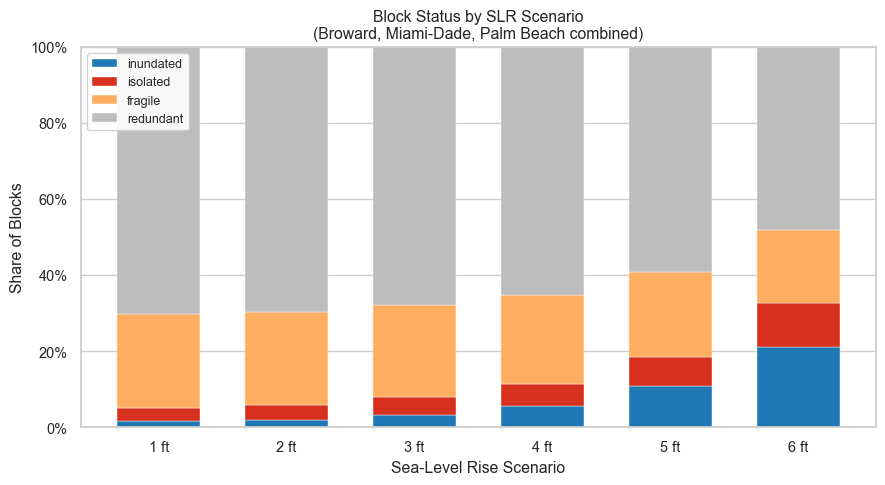

Saved: fig1_status_shares_by_slr.png


In [86]:
# Figure 1: Share of blocks by scenario status across SLR levels
status_by_slr = (
    long_df.loc[long_df["slr_ft"] != 0]
    .groupby(["slr_ft", "scenario_status"])
    .size().reset_index(name="n")
)
total_slr = status_by_slr.groupby("slr_ft")["n"].transform("sum")
status_by_slr["share"] = status_by_slr["n"] / total_slr

pivot = (status_by_slr.pivot_table(index="slr_ft", columns="scenario_status",
                                    values="share", fill_value=0)
                       .reindex(SLR_LEVELS).fillna(0))

fig, ax = plt.subplots(figsize=(9, 5))
x      = np.arange(len(SLR_LEVELS))
bottom = np.zeros(len(SLR_LEVELS))
for status in STATUS_ORDER:
    if status in pivot.columns:
        vals = pivot[status].values
        ax.bar(x, vals, bottom=bottom, label=status,
               color=STATUS_COLORS[status], width=0.65, edgecolor="white", linewidth=0.3)
        bottom += vals

ax.set_xticks(x)
ax.set_xticklabels([f"{ft} ft" for ft in SLR_LEVELS])
ax.set_xlabel("Sea-Level Rise Scenario")
ax.set_ylabel("Share of Blocks")
ax.set_title("Block Status by SLR Scenario\n(Broward, Miami-Dade, Palm Beach combined)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.legend(loc="upper left", framealpha=0.9, fontsize=9)
ax.set_ylim(0, 1)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig1_status_shares_by_slr.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig1_status_shares_by_slr.png")

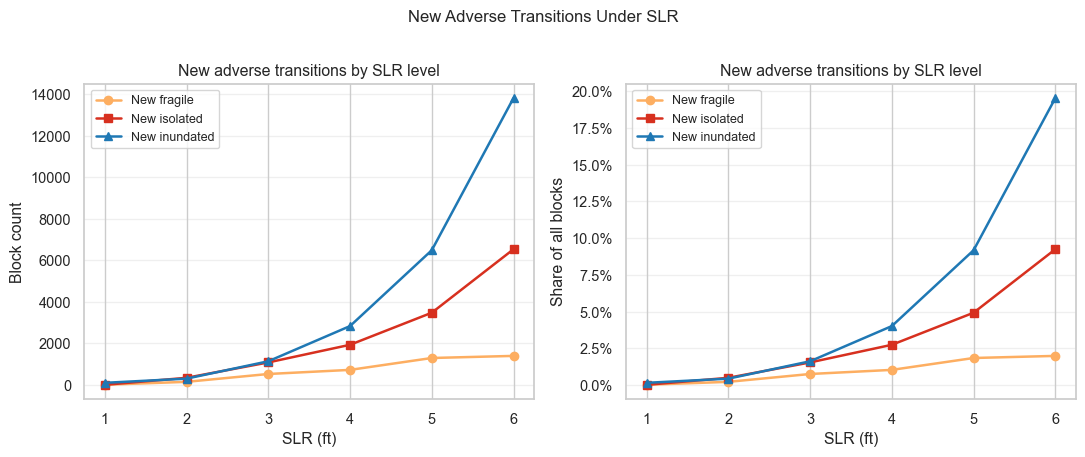

Saved: fig2_new_transitions_by_slr.png


In [87]:
# Figure 2: New adverse transitions by SLR level
n_all = int(transition_own["n_blocks"].iloc[0])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, normalize, ylabel in [
    (axes[0], False, "Block count"),
    (axes[1], True,  "Share of all blocks"),
]:
    for col, label, marker, color in [
        ("n_new_fragile",   "New fragile",    "o", "#fdae61"),
        ("n_new_isolated",  "New isolated",   "s", "#d7301f"),
        ("n_new_inundated", "New inundated",  "^", "#1f78b4"),
    ]:
        vals = transition_own[col] / n_all if normalize else transition_own[col]
        ax.plot(transition_own["slr_ft"], vals, marker=marker,
                color=color, label=label, linewidth=1.8)
    ax.set_xlabel("SLR (ft)")
    ax.set_ylabel(ylabel)
    ax.set_title("New adverse transitions by SLR level")
    if normalize:
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
    ax.set_xticks(SLR_LEVELS)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("New Adverse Transitions Under SLR", fontsize=12, y=1.01)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig2_new_transitions_by_slr.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig2_new_transitions_by_slr.png")

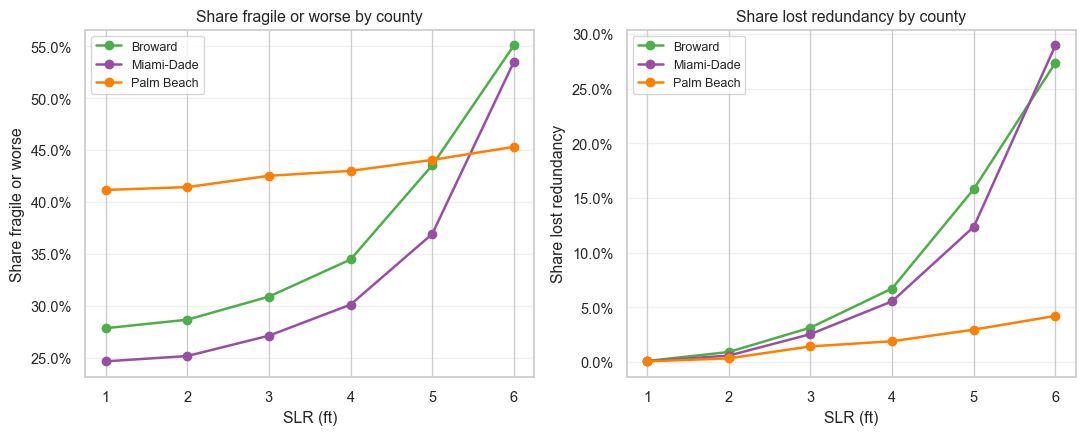

Saved: fig3.png


In [88]:
# Figure 3: County comparison
county_slr = (
    long_df.loc[long_df["slr_ft"] != 0]
    .groupby(["county_name", "slr_ft"])
    .agg(
        total_blocks      = ("block_geoid",           "size"),
        n_fragile_worse   = ("fragile_or_worse",      "sum"),
        n_lost_redundancy = ("any_loss_of_redundancy","sum"),
    ).reset_index()
)
county_slr["share_fragile_or_worse"] = county_slr["n_fragile_worse"]   / county_slr["total_blocks"]
county_slr["share_lost_redundancy"]  = county_slr["n_lost_redundancy"] / county_slr["total_blocks"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, col, title in [
    (axes[0], "share_fragile_or_worse", "Share fragile or worse"),
    (axes[1], "share_lost_redundancy",  "Share lost redundancy"),
]:
    for county, color in COUNTY_COLORS.items():
        sub = county_slr.loc[county_slr["county_name"] == county]
        ax.plot(sub["slr_ft"], sub[col], marker="o", color=color,
                label=county, linewidth=1.8)
    ax.set_xlabel("SLR (ft)")
    ax.set_ylabel(title)
    ax.set_title(title + " by county")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
    ax.set_xticks(SLR_LEVELS)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig3_county_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig3.png")

## Figure 4: Network Transition Decomposition — The Full Story

Standard SLR analyses count inundated blocks. This figure shows why that understates the access problem by missing the network-transition hierarchy.

- **Left panel** — stacked bars decompose *all* network-compromised blocks at each SLR level by the specific origin → destination transition. Hatched segments came from a redundant baseline (new network losses); solid segments were already at-risk and worsened. The dashed line is the naive inundation-only count.
- **Right panel** — three cumulative lines (inundated / isolated-or-worse / fragile-or-worse) with shaded gaps, showing the growing share of access loss that inundation-only analysis fails to capture.


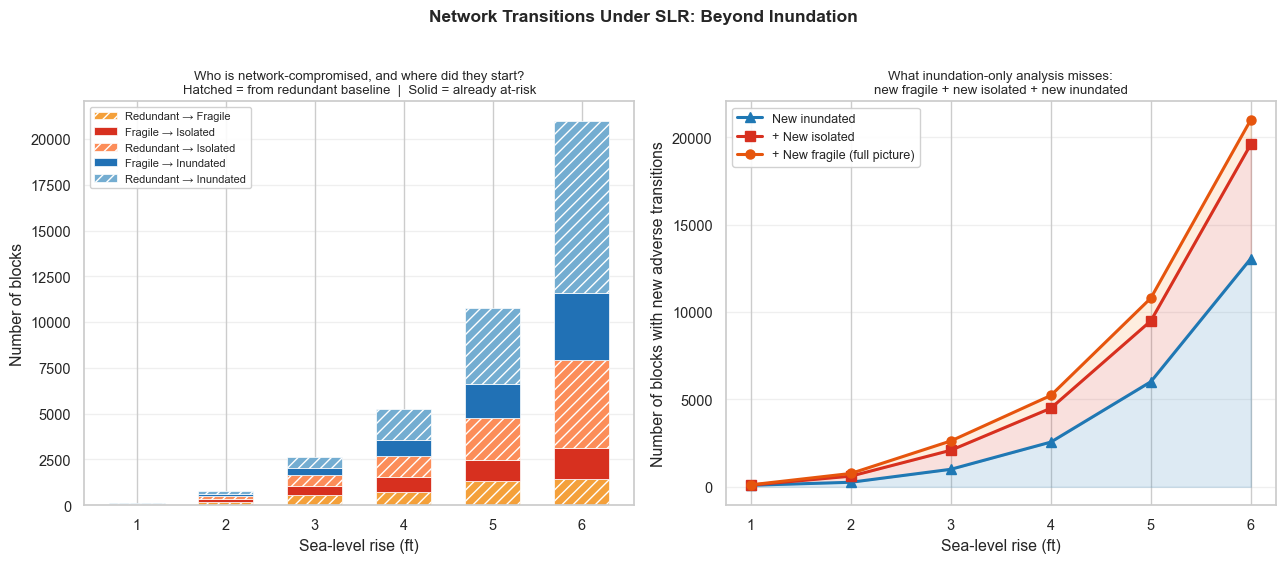

Saved: fig4_network_transition_decomposition.png


In [103]:
import numpy as np

# Figure 4: Network Transition Decomposition — The Full Story
# Left  — stacked bars by transition type; hatching = from redundant baseline.
# Right — cumulative NEW adverse transitions show what inundation-only misses.
# Note: Isolated -> Inundated excluded (baseline-isolated communities not modeled).

# --- Build transition-by-SLR aggregation ---
scen = long_df.loc[long_df["slr_ft"] != 0].copy()

trans_comp = (
    scen.groupby("slr_ft")
    .agg(
        n_blocks  = ("block_geoid",                    "size"),
        n_r_to_f  = ("baseline_redundant_to_fragile",   "sum"),
        n_r_to_i  = ("baseline_redundant_to_isolated",  "sum"),
        n_r_to_in = ("baseline_redundant_to_inundated", "sum"),
        n_f_to_i  = ("baseline_fragile_to_isolated",    "sum"),
        n_f_to_in = ("baseline_fragile_to_inundated",   "sum"),
    )
    .reset_index()
)

# Cumulative new adverse transitions (for right panel)
trans_comp["n_new_inundated"] = trans_comp["n_r_to_in"] + trans_comp["n_f_to_in"]
trans_comp["n_new_iso_plus"]  = trans_comp["n_new_inundated"] + trans_comp["n_r_to_i"] + trans_comp["n_f_to_i"]
trans_comp["n_new_all"]       = trans_comp["n_new_iso_plus"]  + trans_comp["n_r_to_f"]

x = trans_comp["slr_ft"].values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

# ---------------------------------------------------------------
# LEFT PANEL: stacked bars decomposed by origin -> destination
# Ordered bottom->top: Fragile -> Isolated -> Inundated
# Hatching = "came from redundant baseline"  (new network losses)
# Solid    = "already at-risk, now worse"    (cascading exposure)
# ---------------------------------------------------------------
segments = [
    # (column,    label,                  color,     hatch)
    ("n_r_to_f",  "Redundant → Fragile",  "#f4a03a", "///"),
    ("n_f_to_i",  "Fragile → Isolated",   "#d7301f", None),
    ("n_r_to_i",  "Redundant → Isolated", "#fc8d59", "///"),
    ("n_f_to_in", "Fragile → Inundated",  "#2171b5", None),
    ("n_r_to_in", "Redundant → Inundated","#74add1", "///"),
]

bottoms = np.zeros(len(x))
for col, label, color, hatch in segments:
    vals = trans_comp[col].values
    ax1.bar(x, vals, bottom=bottoms, width=0.62,
            color=color, hatch=hatch, edgecolor="white", linewidth=0.5, label=label)
    bottoms += vals

ax1.set_xlabel("Sea-level rise (ft)")
ax1.set_ylabel("Number of blocks")
ax1.set_title(
    "Who is network-compromised, and where did they start?\n"
    "Hatched = from redundant baseline  |  Solid = already at-risk",
    fontsize=9.5
)
ax1.set_xticks(SLR_LEVELS)
ax1.legend(fontsize=8, loc="upper left", framealpha=0.9)
ax1.grid(axis="y", alpha=0.3)

# ---------------------------------------------------------------
# RIGHT PANEL: cumulative new adverse transitions
# Builds up from inundated -> +isolated -> +fragile
# ---------------------------------------------------------------
ax2.fill_between(x, 0, trans_comp["n_new_inundated"],
                 color="#1f78b4", alpha=0.15)
ax2.fill_between(x, trans_comp["n_new_inundated"], trans_comp["n_new_iso_plus"],
                 color="#d7301f", alpha=0.15)
ax2.fill_between(x, trans_comp["n_new_iso_plus"], trans_comp["n_new_all"],
                 color="#fdae61", alpha=0.20)

ax2.plot(x, trans_comp["n_new_inundated"], color="#1f78b4", linewidth=2.2,
         marker="^", markersize=6.5, label="New inundated")
ax2.plot(x, trans_comp["n_new_iso_plus"],  color="#d7301f", linewidth=2.2,
         marker="s", markersize=6.5, label="+ New isolated")
ax2.plot(x, trans_comp["n_new_all"],       color="#e6550d", linewidth=2.2,
         marker="o", markersize=6.5, label="+ New fragile (full picture)")

# Annotate the gap at peak SLR
peak = trans_comp.iloc[-1]
pct_missed = (peak["n_new_all"] - peak["n_new_inundated"]) / peak["n_new_all"] * 100


ax2.set_xlabel("Sea-level rise (ft)")
ax2.set_ylabel("Number of blocks with new adverse transitions")
ax2.set_title(
    "What inundation-only analysis misses:\n"
    "new fragile + new isolated + new inundated",
    fontsize=9.5
)
ax2.set_xticks(SLR_LEVELS)
ax2.legend(fontsize=9, loc="upper left", framealpha=0.9)
ax2.grid(axis="y", alpha=0.3)

plt.suptitle(
    "Network Transitions Under SLR: Beyond Inundation",
    fontsize=12.5, fontweight="bold", y=1.02
)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig4_network_transition_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig4_network_transition_decomposition.png")


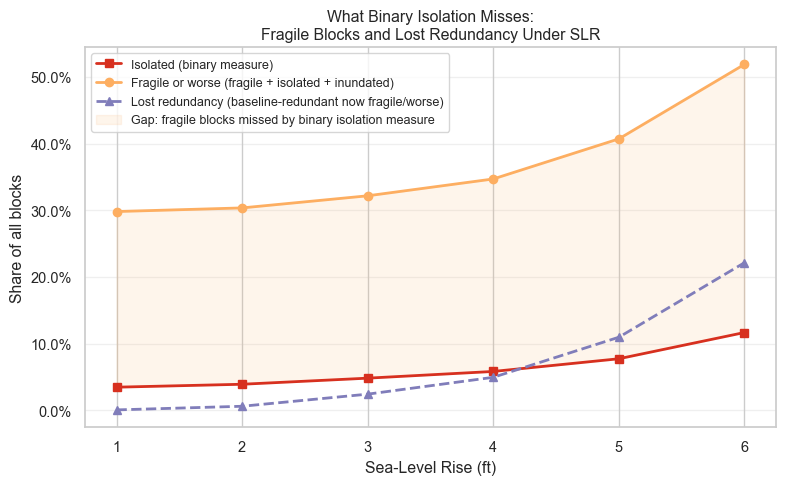

Saved: fig5_isolation_vs_redundancy.png


In [90]:
# Figure 5: Why redundancy measures add information beyond binary isolation
compare_df = (
    long_df.loc[long_df["slr_ft"] != 0]
    .groupby("slr_ft")
    .agg(
        n_blocks           = ("block_geoid",             "size"),
        n_isolated         = ("block_centroid_isolated",  "sum"),
        n_fragile_or_worse = ("fragile_or_worse",         "sum"),
        n_lost_redundancy  = ("any_loss_of_redundancy",   "sum"),
    ).reset_index()
)
compare_df["share_isolated"]         = compare_df["n_isolated"]         / compare_df["n_blocks"]
compare_df["share_fragile_or_worse"] = compare_df["n_fragile_or_worse"] / compare_df["n_blocks"]
compare_df["share_lost_redundancy"]  = compare_df["n_lost_redundancy"]  / compare_df["n_blocks"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(compare_df["slr_ft"], compare_df["share_isolated"],
        marker="s", color="#d7301f", linewidth=2, label="Isolated (binary measure)")
ax.plot(compare_df["slr_ft"], compare_df["share_fragile_or_worse"],
        marker="o", color="#fdae61", linewidth=2,
        label="Fragile or worse (fragile + isolated + inundated)")
ax.plot(compare_df["slr_ft"], compare_df["share_lost_redundancy"],
        marker="^", color="#807dba", linewidth=2, linestyle="--",
        label="Lost redundancy (baseline-redundant now fragile/worse)")
ax.fill_between(
    compare_df["slr_ft"],
    compare_df["share_isolated"],
    compare_df["share_fragile_or_worse"],
    alpha=0.12, color="#fdae61",
    label="Gap: fragile blocks missed by binary isolation measure"
)
ax.set_xlabel("Sea-Level Rise (ft)")
ax.set_ylabel("Share of all blocks")
ax.set_title("What Binary Isolation Misses:\nFragile Blocks and Lost Redundancy Under SLR")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax.set_xticks(SLR_LEVELS)
ax.legend(fontsize=9, loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig5_isolation_vs_redundancy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig5_isolation_vs_redundancy.png")

## 7A. Spatial Visualizations: Fragility, Redundancy, and Demographic Vulnerability

Five static choropleth maps that communicate the central takeaway: **the redundancy/fragility
lens reveals a broader and earlier geography of network vulnerability than binary isolation
alone**.

| Figure | Variable mapped | Purpose |
|--------|-----------------|---------|
| **A** | `share_fragile` at baseline (0 ft) | Pre-SLR single-path dependence |
| **B** | `share_lost_redundancy` at SLR 4-6 ft | Tight small multiples over higher-SLR scenarios |
| **C** | `delta share_fragile_or_worse` at SLR 3 ft | Change from baseline, diverging scale |
| **D** | `share_lost_redundancy` + `pct_nonwhite` at SLR 3 ft | Descriptive demographic companion |
| **E** | transition progression at SLR 3 ft | Nested degradation from baseline redundancy |

Geometry: block polygons dissolved to block-group level from the repo's local GPKG.
Maps are projected to EPSG:32617 (UTM Zone 17N) for accurate rendering.


In [91]:
# ---------------------------------------------------------------------------
# Spatial visualization imports — requires the stat_geo (or equivalent) environment
# ---------------------------------------------------------------------------
try:
    import geopandas as gpd
    from matplotlib.colors import Normalize, TwoSlopeNorm
    from matplotlib.cm import ScalarMappable
    HAS_GEOPANDAS = True
    print(f"geopandas {gpd.__version__} ready.")
except ImportError:
    HAS_GEOPANDAS = False
    print("ERROR: geopandas not installed.")
    print("Run: conda install geopandas  (or activate the stat_geo environment)")
    print("Section 7A cells will no-op gracefully until geopandas is available.")

# Path to the local block polygon file
BLOCKS_GPKG = PROJECT_ROOT / "data" / "processed" / "census" / "blocks" / "fl_tricounty_blocks_2020.gpkg"

# CRS for map rendering — same UTM zone used throughout the analysis
MAP_CRS = "EPSG:32617"


# ---------------------------------------------------------------------------
# Geometry helper functions
# ---------------------------------------------------------------------------

def load_block_polygons(gpkg_path):
    """Load block polygons from the repo GPKG and standardize GEOID columns."""
    if not gpkg_path.exists():
        raise FileNotFoundError(
            f"Block geometry file not found:\n  {gpkg_path}\n"
            "Expected: data/processed/census/blocks/fl_tricounty_blocks_2020.gpkg"
        )
    gdf = gpd.read_file(gpkg_path)

    # The GPKG stores geometry as 'geom'; geopandas usually renames it to 'geometry',
    # but handle both cases defensively.
    if gdf.geometry.name != "geometry" and "geom" in gdf.columns:
        gdf = gdf.set_geometry("geom").rename_geometry("geometry")

    # Rename geoid -> block_geoid (consistent with analysis data)
    if "geoid" in gdf.columns and "block_geoid" not in gdf.columns:
        gdf = gdf.rename(columns={"geoid": "block_geoid"})

    # Standardize zero-padded GEOIDs
    for col, width in [("block_geoid", 15), ("block_group_geoid", 12),
                       ("tract_geoid", 11), ("county_fips", 3)]:
        if col in gdf.columns:
            gdf[col] = gdf[col].astype(str).str.zfill(width)
    return gdf


def dissolve_to_block_groups(blocks_gdf, target_crs=MAP_CRS):
    """Dissolve block polygons to block-group polygons.
    county_fips and county_name are constant within a block group, so 'first' is correct.
    """
    gdf = blocks_gdf.to_crs(target_crs)
    slim = gdf[["block_group_geoid", "county_fips", "county_name", "geometry"]].copy()
    bg = slim.dissolve(by="block_group_geoid", aggfunc="first").reset_index()
    bg["block_group_geoid"] = bg["block_group_geoid"].astype(str).str.zfill(12)
    bg["county_fips"]       = bg["county_fips"].astype(str).str.zfill(3)
    return bg


def make_county_outlines(bg_gdf):
    """Dissolve block-group polygons to county outlines for overlay reference."""
    return (bg_gdf.dissolve(by="county_name", aggfunc="first")
                  .reset_index()[["county_name", "geometry"]])

geopandas 1.1.2 ready.


In [92]:
# ---------------------------------------------------------------------------
# Load block polygons and dissolve to block-group and county geometries
# ---------------------------------------------------------------------------
if not HAS_GEOPANDAS:
    print("geopandas not available — skipping geometry load.")
    bg_geom = None
    county_outlines = None
else:
    print("Loading block polygons (may take ~20–30 s for 70k polygons)...")
    blocks_gdf = load_block_polygons(BLOCKS_GPKG)
    print(f"  {len(blocks_gdf):,} block polygons | CRS: {blocks_gdf.crs.to_epsg()}")

    print("Dissolving to block-group polygons...")
    bg_geom = dissolve_to_block_groups(blocks_gdf)
    del blocks_gdf   # free ~200 MB of block-level geometry
    print(f"  {len(bg_geom):,} block-group polygons | CRS: {bg_geom.crs.to_epsg()}")

    county_outlines = make_county_outlines(bg_geom)
    print(f"  County outlines: {county_outlines['county_name'].tolist()}")

    # Quick sanity: every block group in bg_geom should be in bg_analysis
    bg_geom_ids  = set(bg_geom["block_group_geoid"])
    bg_analy_ids = set(bg_analysis["block_group_geoid"])
    missing_in_analysis = bg_geom_ids - bg_analy_ids
    if missing_in_analysis:
        print(f"  NOTE: {len(missing_in_analysis)} BG polygons have no analysis row "
              f"(will appear gray on maps).")
    else:
        print("  Geometry-to-analysis match: all BG polygons have analysis data.")

Loading block polygons (may take ~20–30 s for 70k polygons)...
  70,695 block polygons | CRS: 4269
Dissolving to block-group polygons...
  3,946 block-group polygons | CRS: 32617
  County outlines: ['Broward', 'Miami-Dade', 'Palm Beach']
  Geometry-to-analysis match: all BG polygons have analysis data.


In [93]:
# ---------------------------------------------------------------------------
# Build the map GeoDataFrame: geometry + analysis + baseline reference columns
# ---------------------------------------------------------------------------
if not HAS_GEOPANDAS or bg_geom is None:
    print("Skipping map data prep - geometry not loaded.")
    map_gdf = None
else:
    # bg_geom:     one row per block_group_geoid (geometry)
    # bg_analysis: one row per (block_group_geoid, slr_ft)
    map_gdf = bg_geom.merge(
        bg_analysis,
        on="block_group_geoid",
        how="left",
        validate="one_to_many",
    )

    # Drop geometry-side duplicates that arise from the merge key collision
    for dup in ["county_fips_x", "county_name_x", "county_fips_y", "county_name_y"]:
        if dup in map_gdf.columns:
            clean = dup.rstrip("_xy")
            if clean not in map_gdf.columns:
                map_gdf = map_gdf.rename(columns={dup: clean})
            else:
                map_gdf = map_gdf.drop(columns=[dup])

    map_gdf = gpd.GeoDataFrame(map_gdf, geometry="geometry", crs=MAP_CRS)

    # ------------------------------------------------------------------
    # Baseline reference columns (join slr_ft==0 back as reference)
    # ------------------------------------------------------------------
    # These enable delta maps: how much did fragility change vs. pre-SLR?
    baseline_ref = (
        map_gdf.loc[map_gdf["slr_ft"] == 0,
                    ["block_group_geoid", "share_fragile_or_worse", "share_fragile"]]
        .rename(columns={
            "share_fragile_or_worse": "baseline_share_fragile_or_worse",
            "share_fragile":          "baseline_share_fragile",
        })
        .drop_duplicates("block_group_geoid")
    )
    map_gdf = map_gdf.merge(baseline_ref, on="block_group_geoid", how="left")

    # Change from baseline: positive = more fragility than at baseline
    map_gdf["delta_fragile_or_worse"] = (
        map_gdf["share_fragile_or_worse"] - map_gdf["baseline_share_fragile_or_worse"]
    )

    map_gdf = gpd.GeoDataFrame(map_gdf, geometry="geometry", crs=MAP_CRS)

    n_bgs  = map_gdf["block_group_geoid"].nunique()
    n_rows = len(map_gdf)
    print(f"map_gdf: {n_rows:,} rows  ({n_bgs:,} block groups x {map_gdf['slr_ft'].nunique()} SLR levels)")

    # Preview the key mapping columns
    preview_cols = [c for c in [
        "share_fragile", "share_isolated", "share_fragile_or_worse",
        "share_lost_redundancy", "delta_fragile_or_worse",
        "pct_nonwhite", "pct_age_65plus", "no_vehicle_share", "poverty_rate", "renter_share",
    ] if c in map_gdf.columns]
    slr3 = map_gdf.loc[map_gdf["slr_ft"] == 3, preview_cols]
    display(slr3.describe().loc[["mean", "50%", "max"]].rename(index={"50%": "median"}).round(4))

map_gdf: 27,622 rows  (3,946 block groups x 7 SLR levels)


,share_fragile,share_isolated,share_fragile_or_worse,share_lost_redundancy,delta_fragile_or_worse,pct_nonwhite,pct_age_65plus,no_vehicle_share,poverty_rate,renter_share
mean,0.2727,0.0662,0.3827,0.0314,0.0314,0.6850,0.2101,0.0769,NaN,0.3819
median,0.2143,0.0000,0.3000,0.0000,0.0000,0.7736,0.1642,0.0386,NaN,0.3259
max,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.7330,NaN,1.0000


In [94]:
# ---------------------------------------------------------------------------
# Map plotting helper functions (reused across all figures in 7A)
# ---------------------------------------------------------------------------

def _clean_ax(ax):
    """Remove ticks and frame for a clean map panel."""
    ax.set_axis_off()


def choropleth(ax, gdf, col, cmap, norm, county_gdf=None, title="", subtitle=""):
    """
    Draw a choropleth on ax.

    Approach: paint all block groups gray first (background / missing data),
    then overlay rows with valid data using the specified cmap/norm.
    County outlines are added last.

    Parameters
    ----------
    ax            : matplotlib Axes
    gdf           : GeoDataFrame with geometry and `col`
    col           : column name to map
    cmap          : matplotlib colormap name or object
    norm          : matplotlib Normalize or TwoSlopeNorm
    county_gdf    : optional GeoDataFrame of county outlines
    title         : panel title (bold)
    subtitle      : smaller text below the panel
    """
    # 1. Gray background for all polygons (catches missing-value areas too)
    gdf.plot(ax=ax, color="#e8e8e8", linewidth=0)

    # 2. Choropleth: only rows with valid (non-NaN) data
    valid = gdf.loc[gdf[col].notna()].copy()
    if not valid.empty:
        valid.plot(ax=ax, column=col, cmap=cmap, norm=norm,
                   linewidth=0, legend=False)

    # 3. Optional county outlines for geographic reference.
    # Skip them for the Figure E transition panels so filtered-population
    # maps do not inherit extra whitespace from the full county extent.
    outline_exempt_cols = {
        "share_transition_to_inundation",
        "share_transition_to_isolation_or_worse",
        "share_transition_to_fragile_or_worse",
    }
    if county_gdf is not None and col not in outline_exempt_cols:
        county_gdf.boundary.plot(ax=ax, color="#333333", linewidth=0.9, zorder=5)

    if title:
        ax.set_title(title, fontsize=9.5, fontweight="bold", pad=3)
    if subtitle:
        ax.text(0.5, -0.02, subtitle, transform=ax.transAxes,
                ha="center", fontsize=7.5, color="#555555", style="italic")
    _clean_ax(ax)


def add_colorbar(fig, ax_or_axes, cmap, norm, label="", pct=False):
    """
    Attach a colorbar to fig.

    ax_or_axes : single Axes or list of Axes (for shared colorbar in small multiples)
    pct        : if True, format tick labels as percentages (assumes values 0–1)
    """
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax_or_axes, fraction=0.022, pad=0.02, shrink=0.65)
    if pct:
        cbar.ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f"{x:.0%}")
        )
    cbar.set_label(label, fontsize=9)
    cbar.ax.tick_params(labelsize=8)
    return cbar


print("Map helper functions defined: choropleth(), add_colorbar()")

Map helper functions defined: choropleth(), add_colorbar()


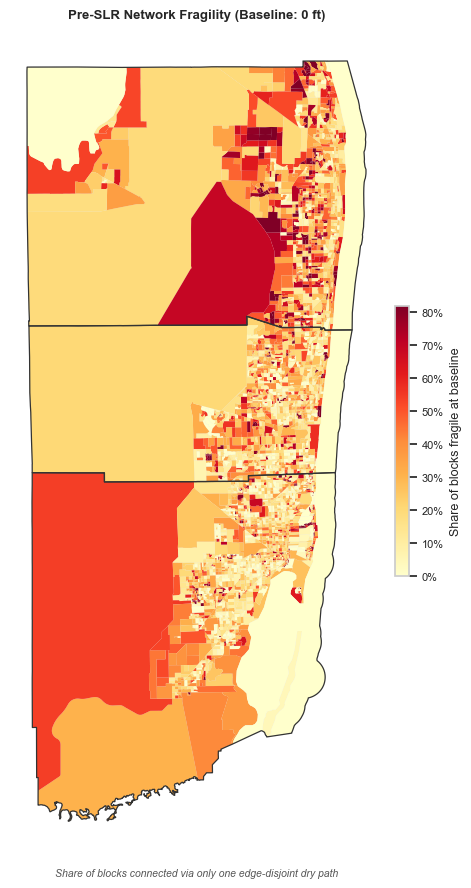

Saved: figA_baseline_fragility_map.png
  Color scale: 0 to 81.8% (95th percentile of baseline share_fragile)


In [95]:
# ---------------------------------------------------------------------------
# Figure A: Baseline network fragility (share_fragile at slr_ft == 0)
#
# Why: shows which block groups were already single-path-dependent BEFORE any
# additional SLR, i.e., pre-existing structural vulnerability in the network.
# A block group with high share_fragile has many blocks that have only ONE
# edge-disjoint dry route at the baseline scenario.
# Color scale: 0 to 95th-pct (prevents outliers from compressing the scale).
# ---------------------------------------------------------------------------
if map_gdf is None:
    print("map_gdf not built — skipping Figure A.")
else:
    data_a = map_gdf.loc[map_gdf["slr_ft"] == 0].copy()

    # Compute vmax dynamically as the 95th percentile of the distribution
    vmax_a = float(data_a["share_fragile"].quantile(0.95))
    vmax_a = max(vmax_a, 0.01)   # guard against near-zero edge case
    norm_a = Normalize(vmin=0, vmax=vmax_a)
    cmap_a = "YlOrRd"

    fig, ax = plt.subplots(figsize=(7, 9))
    choropleth(
        ax, data_a, "share_fragile", cmap_a, norm_a, county_outlines,
        title="Pre-SLR Network Fragility (Baseline: 0 ft)",
        subtitle="Share of blocks connected via only one edge-disjoint dry path",
    )
    add_colorbar(fig, ax, cmap_a, norm_a, label="Share of blocks fragile at baseline", pct=True)

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "figA_baseline_fragility_map.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: figA_baseline_fragility_map.png")
    print(f"  Color scale: 0 to {vmax_a:.1%} (95th percentile of baseline share_fragile)")

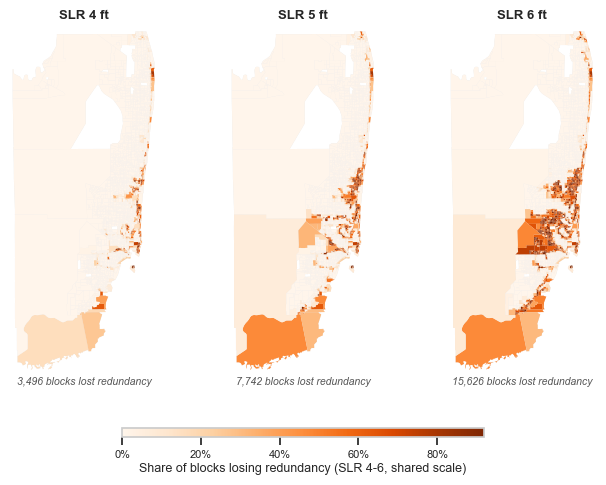

Saved: figB_lost_redundancy_small_multiples.png
  Shared color scale vmax = 91.9% (95th pct at SLR 6ft)
  Filter: filtered to block groups with total_pop > 0
  Map extent: x=509727-598766  y=2775100-2988600


In [96]:
# ---------------------------------------------------------------------------
# Figure B: Higher-SLR small multiples - share_lost_redundancy at SLR 4, 5, and 6
#
# This figure focuses on the higher-end SLR scenarios where redundancy loss is most
# visible. Like Figure E, county outlines are omitted to avoid extra whitespace,
# and the map is filtered to populated block groups only when total_pop is available.
# ---------------------------------------------------------------------------
from matplotlib.ticker import PercentFormatter

if map_gdf is None:
    print("Skipping Figure B.")
else:
    DISPLAY_SLRS = [4, 5, 6]
    map_b = map_gdf.loc[map_gdf["slr_ft"].isin(DISPLAY_SLRS)].copy()

    if "total_pop" in map_b.columns:
        map_b = map_b.loc[map_b["total_pop"].fillna(0).gt(0)].copy()
        pop_note = "filtered to block groups with total_pop > 0"
    else:
        pop_note = "total_pop unavailable; no population filter applied"

    if map_b.empty:
        print("Skipping Figure B - no populated block groups available after filtering.")
    else:
        scale_data = map_b.loc[map_b["slr_ft"] == max(DISPLAY_SLRS), "share_lost_redundancy"].dropna()
        if scale_data.empty:
            scale_data = map_b["share_lost_redundancy"].dropna()
        vmax_b = float(scale_data.quantile(0.95)) if not scale_data.empty else 0.01
        vmax_b = max(vmax_b, 0.01)
        norm_b = Normalize(vmin=0, vmax=vmax_b)
        cmap_b = "Oranges"

        active = map_b.loc[map_b["share_lost_redundancy"].gt(0)].copy()
        if active.empty:
            active = map_b.copy()
        xmin, ymin, xmax, ymax = active.total_bounds
        pad_x = (xmax - xmin) * 0.025
        pad_y = (ymax - ymin) * 0.025
        xlim = (xmin - pad_x, xmax + pad_x)
        ylim = (ymin - pad_y, ymax + pad_y)

        map_ratio = max((xlim[1] - xlim[0]) / max(ylim[1] - ylim[0], 1), 0.24)
        panel_height = 5.0
        panel_width = max(panel_height * map_ratio, 1.7)
        fig_width = panel_width * len(DISPLAY_SLRS) + 0.45

        fig, axes = plt.subplots(
            1,
            3,
            figsize=(fig_width, panel_height),
            gridspec_kw={"wspace": 0.0},
        )

        for ax, slr_ft in zip(axes, DISPLAY_SLRS):
            data = map_b.loc[map_b["slr_ft"] == slr_ft].copy()
            n_lost = int(data["any_loss_of_redundancy"].sum()) if "any_loss_of_redundancy" in data.columns else 0
            choropleth(
                ax,
                data,
                "share_lost_redundancy",
                cmap_b,
                norm_b,
                None,
                title=f"SLR {slr_ft} ft",
                subtitle=f"{n_lost:,} blocks lost redundancy",
            )
            ax.set_xlim(xlim)
            ax.set_ylim(ylim)
            ax.set_anchor("C")

        fig.subplots_adjust(left=0.01, right=0.99, top=0.91, bottom=0.20, wspace=0.0)

        sm = ScalarMappable(norm=norm_b, cmap=cmap_b)
        sm.set_array([])
        cax = fig.add_axes([0.23, 0.082, 0.54, 0.018])
        cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
        cbar.set_label(
            "Share of blocks losing redundancy (SLR 4-6, shared scale)",
            fontsize=9,
            labelpad=2,
        )
        cbar.ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))
        cbar.ax.tick_params(labelsize=8)

        fig.savefig(
            FIGURES_DIR / "figB_lost_redundancy_small_multiples.png",
            dpi=150,
            bbox_inches="tight",
        )
        plt.show()

        print("Saved: figB_lost_redundancy_small_multiples.png")
        print(f"  Shared color scale vmax = {vmax_b:.1%} (95th pct at SLR 6ft)")
        print(f"  Filter: {pop_note}")
        print(f"  Map extent: x={xlim[0]:.0f}-{xlim[1]:.0f}  y={ylim[0]:.0f}-{ylim[1]:.0f}")


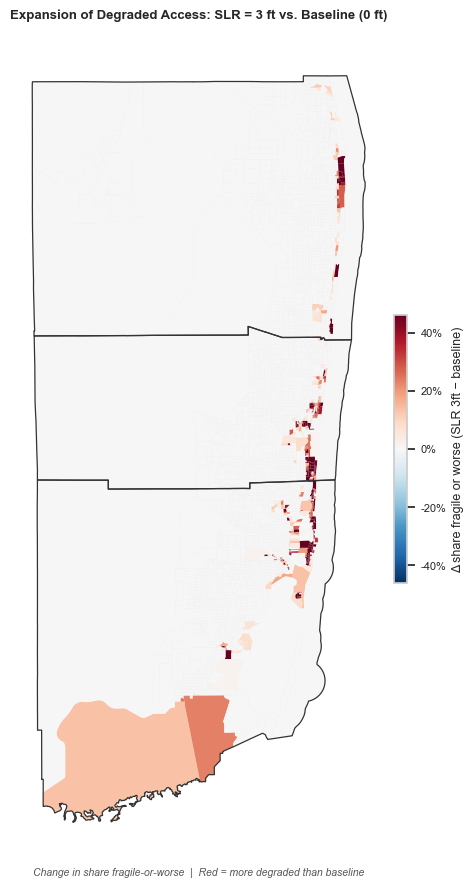

Saved: figC_delta_fragile_or_worse_slr3.png
  Diverging scale: ±46.0%  (97th pct of |delta|)


In [97]:
# ---------------------------------------------------------------------------
# Figure C: Change in degraded access from baseline (SLR = 3 ft)
#
# Maps delta_fragile_or_worse = share_fragile_or_worse(SLR=3) - share_fragile_or_worse(baseline=0)
# Positive values (red) = more blocks fragile/worse than at baseline.
# Negative values (blue) = fewer fragile/worse blocks than baseline (rare/impossible
# in most cases since SLR doesn't improve connectivity, but guard against data quirks).
#
# Diverging scale centered at 0 — TwoSlopeNorm with symmetric bounds.
# Using 97th pct of |delta| as the scale bound to avoid extreme outlier stretch.
# ---------------------------------------------------------------------------
if map_gdf is None:
    print("Skipping Figure C.")
else:
    SLR_FOR_C = 3
    data_c = map_gdf.loc[map_gdf["slr_ft"] == SLR_FOR_C].copy()

    max_abs_c = float(data_c["delta_fragile_or_worse"].abs().quantile(0.97))
    max_abs_c = max(max_abs_c, 0.01)

    # TwoSlopeNorm: diverging colormap centered at 0
    norm_c = TwoSlopeNorm(vmin=-max_abs_c, vcenter=0.0, vmax=max_abs_c)
    cmap_c = "RdBu_r"   # red = increased fragility, blue = decreased

    fig, ax = plt.subplots(figsize=(7, 9))
    choropleth(
        ax, data_c, "delta_fragile_or_worse", cmap_c, norm_c, county_outlines,
        title=f"Expansion of Degraded Access: SLR = {SLR_FOR_C} ft vs. Baseline (0 ft)",
        subtitle="Change in share fragile-or-worse  |  Red = more degraded than baseline",
    )
    add_colorbar(fig, ax, cmap_c, norm_c,
                 label="Δ share fragile or worse (SLR 3ft − baseline)", pct=True)

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "figC_delta_fragile_or_worse_slr3.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: figC_delta_fragile_or_worse_slr3.png")
    print(f"  Diverging scale: ±{max_abs_c:.1%}  (97th pct of |delta|)")

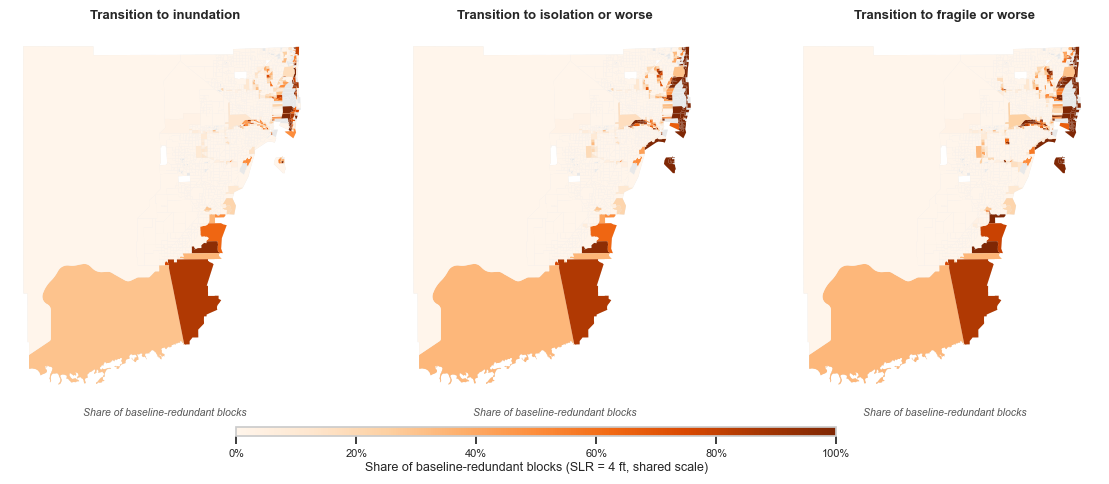

Saved: figE_transition_progression_slr4.png
  Shared vmax = 100.0%  (95th pct of share_transition_to_fragile_or_worse at SLR 4ft)
  Map extent: x=509043–594407  y=2773668–2879771  (375 BGs with transitions)

Section 7A figure files:
  figA_baseline_fragility_map.png  (saved)
  figB_lost_redundancy_small_multiples.png  (saved)
  figC_delta_fragile_or_worse_slr3.png  (saved)
  figD_vulnerability_demography_slr3.png  (saved)
  figE_transition_progression_slr3.png  (saved)


In [98]:
# ---------------------------------------------------------------------------
# Figure E: SLR-induced transition progression from baseline redundancy — SLR = 4 ft
#
# Three transition metrics, all anchored to blocks that were BASELINE REDUNDANT.
# Denominator: n_baseline_redundant (blocks with redundant access at SLR = 0 ft)
#
# Left:   Transition to inundation        (most severe terminal outcome)
# Middle: Transition to isolation or worse (isolated + inundated)
# Right:  Transition to fragile or worse   (broadest degradation from redundancy)
#
# This answers: among places that were baseline-redundant, where does SLR
# push them into inundation, isolation, or fragility?
#
# Shared color scale anchored to 95th pct of the broadest metric (Right panel),
# so the three panels read as an ordered nested progression.
# Map extent is zoomed dynamically to the coastal area where transitions occur.
# ---------------------------------------------------------------------------
from matplotlib.ticker import PercentFormatter

if map_gdf is None:
    print("Skipping Figure E.")
else:
    SLR_FOR_E = 4

    # ------------------------------------------------------------------
    # Step 1: Baseline-redundant block count per block group
    # At slr_ft == 0, block_centroid_redundant IS the baseline redundant count.
    # ------------------------------------------------------------------
    baseline_n_red = (
        map_gdf.loc[map_gdf["slr_ft"] == 0,
                    ["block_group_geoid", "block_centroid_redundant"]]
        .rename(columns={"block_centroid_redundant": "n_baseline_redundant"})
        .drop_duplicates("block_group_geoid")
    )

    # ------------------------------------------------------------------
    # Step 2: Slice SLR = 4, merge denominator, compute transition shares
    # ------------------------------------------------------------------
    data_e = map_gdf.loc[(map_gdf["slr_ft"] == SLR_FOR_E) & 
                        (map_gdf["county_name"] == "Miami-Dade") &
                        (map_gdf["total_pop"] > 0)
    ].copy()
    data_e = data_e.merge(baseline_n_red, on="block_group_geoid", how="left")

    # Numerators (block-group sums already computed in bg_analysis, cell 18)
    # A: baseline-redundant -> inundated (most severe terminal state)
    data_e["_num_inundation"] = data_e["baseline_redundant_to_inundated"]
    # B: baseline-redundant -> isolated OR inundated
    data_e["_num_isolation_or_worse"] = (
        data_e["baseline_redundant_to_isolated"]
        + data_e["baseline_redundant_to_inundated"]
    )
    # C: baseline-redundant -> fragile OR isolated OR inundated (any_loss_of_redundancy)
    data_e["_num_fragile_or_worse"] = data_e["any_loss_of_redundancy"]

    # Transition shares — NaN where no baseline-redundant blocks exist
    denom = data_e["n_baseline_redundant"].replace(0, np.nan)
    data_e["share_transition_to_inundation"]         = data_e["_num_inundation"]         / denom
    data_e["share_transition_to_isolation_or_worse"] = data_e["_num_isolation_or_worse"] / denom
    data_e["share_transition_to_fragile_or_worse"]   = data_e["_num_fragile_or_worse"]   / denom

    # ------------------------------------------------------------------
    # Step 3: Shared scale — anchored to broadest metric (Right panel)
    # ------------------------------------------------------------------
    vmax_e = float(data_e["share_transition_to_fragile_or_worse"].quantile(0.95))
    vmax_e = max(vmax_e, 0.01)
    norm_e = Normalize(vmin=0, vmax=vmax_e)
    cmap_e = "Oranges"

    # ------------------------------------------------------------------
    # Step 3b: Dynamic zoom — extent of block groups with any transition
    # Subset to BGs where share_transition_to_fragile_or_worse > 0,
    # compute their total bounds, and add 7% padding on each side.
    # ------------------------------------------------------------------
    active = data_e.loc[data_e["share_transition_to_fragile_or_worse"].gt(0)]
    if active.empty:
        # Fallback: use full extent of all BGs
        xmin, ymin, xmax, ymax = data_e.total_bounds
    else:
        xmin, ymin, xmax, ymax = active.total_bounds

    pad_x = (xmax - xmin) * 0.07
    pad_y = (ymax - ymin) * 0.07
    xlim = (xmin - pad_x, xmax + pad_x)
    ylim = (ymin - pad_y, ymax + pad_y)

    # ------------------------------------------------------------------
    # Step 4: Three-panel figure — styled like Figure B
    # ------------------------------------------------------------------
    PANEL_CONFIGS = [
        ("share_transition_to_inundation",         "Transition to inundation"),
        ("share_transition_to_isolation_or_worse", "Transition to isolation or worse"),
        ("share_transition_to_fragile_or_worse",   "Transition to fragile or worse"),
    ]
    SUBTITLE = "Share of baseline-redundant blocks"

    fig, axes = plt.subplots(
        1, 3,
        figsize=(15, 5),
        gridspec_kw={"wspace": 0.02},
    )

    for ax, (col, title) in zip(axes, PANEL_CONFIGS):
        choropleth(ax, data_e, col, cmap_e, norm_e, county_outlines,
                   title=title, subtitle=SUBTITLE)
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)

    plt.tight_layout(rect=[0, 0.10, 1, 1])

    # Compact horizontal colorbar below panels
    sm = ScalarMappable(norm=norm_e, cmap=cmap_e)
    sm.set_array([])
    cax = fig.add_axes([0.30, 0.055, 0.40, 0.018])
    cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
    cbar.set_label(
        "Share of baseline-redundant blocks (SLR = 4 ft, shared scale)",
        fontsize=9, labelpad=2,
    )
    cbar.ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))
    cbar.ax.tick_params(labelsize=8)

    fig.savefig(
        FIGURES_DIR / "figE_transition_progression_slr4.png",
        dpi=150, bbox_inches="tight",
    )
    plt.show()
    print("Saved: figE_transition_progression_slr4.png")
    print(f"  Shared vmax = {vmax_e:.1%}  (95th pct of share_transition_to_fragile_or_worse at SLR {SLR_FOR_E}ft)")
    print(f"  Map extent: x={xlim[0]:.0f}–{xlim[1]:.0f}  y={ylim[0]:.0f}–{ylim[1]:.0f}  ({len(active):,} BGs with transitions)")

# Print summary of saved map files
saved_maps = [
    "figA_baseline_fragility_map.png",
    "figB_lost_redundancy_small_multiples.png",
    "figC_delta_fragile_or_worse_slr3.png",
    "figD_vulnerability_demography_slr3.png",
    "figE_transition_progression_slr3.png",
]
print("\nSection 7A figure files:")
for f in saved_maps:
    p = FIGURES_DIR / f
    status = "saved" if p.exists() else "not yet saved"
    print(f"  {f}  ({status})")

### Section 7A - What Each Map Shows

**Figure A** (`figA_baseline_fragility_map.png`)
Baseline fragility reveals that some block groups were *already* single-path-dependent
before any additional SLR. This pre-existing structural fragility matters because these
areas have no resilience margin - any incremental inundation can sever their only remaining
dry route.

**Figure B** (`figB_lost_redundancy_small_multiples.png`)
The three panels focus on SLR 4, 5, and 6 only, where loss of redundancy is most visible.
The figure is filtered to block groups with `total_pop > 0` when that column is available,
and county outlines are omitted so the maps can zoom tightly to the active geography.

**Figure C** (`figC_delta_fragile_or_worse_slr3.png`)
The change-from-baseline map shows where SLR 3ft expands the geography of degraded access
beyond what was already present at baseline. Blocks that were already fragile at baseline
appear near zero (no additional change); the red areas are places where SLR converts
previously redundant blocks into fragile/worse.

**Figure D** (`figD_vulnerability_demography_slr3.png`)
The two-panel companion is exploratory and descriptive. Spatial co-occurrence between
network fragility and non-white population share does not imply causation - both are
driven by underlying geography and the distribution of the road network. Areas of overlap
warrant further disaggregated analysis.

**Figure E** (`figE_transition_progression_slr3.png`)
Three transition metrics are shown side by side for a single SLR scenario, all anchored to
baseline-redundant blocks. The figure traces a nested progression from inundation to
isolation-or-worse to fragile-or-worse.

> **TODO:** If you want inset maps zooming into specific hotspot areas
> (e.g., coastal corridors in Miami-Dade), they can be added by filtering
> `map_gdf` to a bounding box and re-running the `choropleth()` helper.


In [99]:
# ---------------------------------------------------------------------------
# Export map_gdf to GeoPackage for QGIS
#
# One layer per SLR scenario (slr_0ft ... slr_6ft) + one stacked "all_scenarios"
# layer for filtering in QGIS.
#
# Format: GeoPackage (.gpkg) - preferred over Shapefile because:
#   * No 10-character column-name truncation
#   * Single self-contained file
#   * Supports multiple named layers
#
# CRS: EPSG:32617 (UTM Zone 17N) - same as the analysis.
# QGIS reprojects on-the-fly; no conversion needed before loading.
# ---------------------------------------------------------------------------
from ast import In

if map_gdf is None:
    print("map_gdf not built - run the Section 7A geometry cells first.")
else:
    SPATIAL_DIR = PROJECT_ROOT / "outputs" / "spatial"
    SPATIAL_DIR.mkdir(parents=True, exist_ok=True)
    GPKG_OUT = SPATIAL_DIR / "slr_block_group_analysis.gpkg"

    # ------------------------------------------------------------------
    # Columns to export
    # Full names preserved by GeoPackage (no shapefile truncation).
    # ------------------------------------------------------------------
    EXPORT_COLS = [
        # Identifiers
        "block_group_geoid", "county_fips", "county_name", "tract_geoid", "slr_ft",
        "total_blocks",
        # Core access-status shares
        "share_inundated", "share_isolated", "share_fragile", "share_redundant",
        "share_fragile_or_worse", "share_lost_redundancy",
        "share_new_fragile", "share_new_isolated", "share_new_inundated",
        # Baseline reference and change-from-baseline
        "baseline_share_fragile", "baseline_share_fragile_or_worse",
        "delta_fragile_or_worse",
        # Path inflation ratio (dry-path / baseline-path)
        "mean_path_inflation_ratio", "median_path_inflation_ratio",
        # Edge-disjoint path counts
        "mean_max_edge_disjoint_paths", "median_max_edge_disjoint_paths",
        # Key transition counts (useful for labeling / graduated symbols in QGIS)
        "any_loss_of_redundancy",
        "new_fragile_due_to_slr", "new_isolated_due_to_slr", "new_inundated_due_to_slr",
        "baseline_redundant_to_fragile", "baseline_redundant_to_isolated",
        "baseline_redundant_to_inundated",
    ]
    # Append demographic columns if the census merge ran successfully
    EXPORT_COLS += [c for c in [
        "total_pop", "median_income", "median_age",
        "hh_no_vehicle", "no_vehicle_share",
        "pop_age_65plus", "pct_age_65plus",
        "pct_nonwhite", "pct_black_nh", "pct_hispanic",
        "renter_share", "poverty_rate", "log_median_income",
    ] if c in map_gdf.columns]

    # Keep only columns that actually exist in map_gdf
    EXPORT_COLS = [c for c in EXPORT_COLS if c in map_gdf.columns]

    export_gdf = map_gdf[EXPORT_COLS + ["geometry"]].copy()

    # Remove stale file so we can write fresh layers without conflicts
    if GPKG_OUT.exists():
        GPKG_OUT.unlink()

    # Write one layer per SLR level
    slr_levels_present = sorted(export_gdf["slr_ft"].unique())
    for slr_ft_val in slr_levels_present:
        layer_name = f"slr_{slr_ft_val}ft"
        layer_data = export_gdf.loc[export_gdf["slr_ft"] == slr_ft_val].drop(columns=["slr_ft"])
        layer_data.to_file(GPKG_OUT, layer=layer_name, driver="GPKG")
        n_bg = len(layer_data)
        print(f"  Layer '{layer_name}': {n_bg:,} block groups")

    # Write a stacked all-scenarios layer (handy for SLR-level filtering in QGIS)
    export_gdf.to_file(GPKG_OUT, layer="all_scenarios", driver="GPKG")

    file_mb = GPKG_OUT.stat().st_size / (1024 ** 2)
    layer_names = [f"slr_{s}ft" for s in slr_levels_present] + ["all_scenarios"]
print(f"\nSaved: {GPKG_OUT}")
print(f"  Size   : {file_mb:.1f} MB")
print(f"  Layers : {layer_names}")
print(f"  CRS    : EPSG:32617  (UTM Zone 17N)")
print(f"  Columns: {len(EXPORT_COLS)} analysis columns + geometry")
print("\nIn QGIS: Layer > Add Layer > Add Vector Layer, or drag the .gpkg file in.")
print("Each SLR layer is a standalone snapshot; 'all_scenarios' lets you filter by slr_ft.")

  Layer 'slr_0ft': 3,946 block groups
  Layer 'slr_1ft': 3,946 block groups
  Layer 'slr_2ft': 3,946 block groups
  Layer 'slr_3ft': 3,946 block groups
  Layer 'slr_4ft': 3,946 block groups
  Layer 'slr_5ft': 3,946 block groups
  Layer 'slr_6ft': 3,946 block groups

Saved: C:\Users\Vivek\Dropbox\repos\slr_fl_fragile_access\outputs\spatial\slr_block_group_analysis.gpkg
  Size   : 99.2 MB
  Layers : ['slr_0ft', 'slr_1ft', 'slr_2ft', 'slr_3ft', 'slr_4ft', 'slr_5ft', 'slr_6ft', 'all_scenarios']
  CRS    : EPSG:32617  (UTM Zone 17N)
  Columns: 42 analysis columns + geometry

In QGIS: Layer > Add Layer > Add Vector Layer, or drag the .gpkg file in.
Each SLR layer is a standalone snapshot; 'all_scenarios' lets you filter by slr_ft.


## 8. Save All Outputs

Write analysis-ready files to disk.

In [100]:
# ---------------------------------------------------------------------------
# Save all outputs to disk (CSV only!)
# ---------------------------------------------------------------------------

# 1. Block-level long dataset
block_csv_out = ANALYSIS_DIR / "block_level_long_dataset.csv"
long_df.to_csv(block_csv_out, index=False)
print(f"Saved: {block_csv_out}")

# Also a CSV sample for quick inspection
sample_out = ANALYSIS_DIR / "block_level_long_dataset_sample5k.csv"
long_df.sample(n=min(5000, len(long_df)), random_state=42).to_csv(sample_out, index=False)
print(f"Saved sample: {sample_out}")

# 2. Block-group analysis dataset
bg_csv_out = ANALYSIS_DIR / "block_group_analysis_dataset.csv"
bg_analysis.to_csv(bg_csv_out, index=False)
print(f"Saved: {bg_csv_out}")

# 3. Tract-level dataset
if "tract_df" in locals() and tract_df is not None:
    tract_csv_out = ANALYSIS_DIR / "tract_analysis_dataset.csv"
    tract_df.to_csv(tract_csv_out, index=False)
    print(f"Saved: {tract_csv_out}")
else:
    print("No tract-level dataset to save.")

# 4. Transition summary tables
transition_out = TABLES_DIR / "transition_summary_by_slr.csv"
crosstab_out = TABLES_DIR / "baseline_vs_scenario_crosstab_validated.csv"

transition_own.to_csv(transition_out, index=False)
crosstab_own.to_csv(crosstab_out, index=False)

print(f"Saved: {transition_out}")
print(f"Saved: {crosstab_out}")

# 5. Regression results (if available)
if "results_df" in locals() and results_df is not None:
    regression_out = TABLES_DIR / "regression_summary.csv"
    results_df.to_csv(regression_out, index=False)
    print(f"Saved: {regression_out}")
else:
    print("No regression results to save (Section 8 not run or demographics unavailable).")

print("\nAll outputs saved.")
print(f"  Analysis data : {ANALYSIS_DIR}")
print(f"  Figures       : {FIGURES_DIR}")
print(f"  Tables        : {TABLES_DIR}")

Saved: C:\Users\Vivek\Dropbox\repos\slr_fl_fragile_access\data\processed\analysis\block_level_long_dataset.csv
Saved sample: C:\Users\Vivek\Dropbox\repos\slr_fl_fragile_access\data\processed\analysis\block_level_long_dataset_sample5k.csv
Saved: C:\Users\Vivek\Dropbox\repos\slr_fl_fragile_access\data\processed\analysis\block_group_analysis_dataset.csv
Saved: C:\Users\Vivek\Dropbox\repos\slr_fl_fragile_access\data\processed\analysis\tract_analysis_dataset.csv
Saved: C:\Users\Vivek\Dropbox\repos\slr_fl_fragile_access\outputs\tables\transition_summary_by_slr.csv
Saved: C:\Users\Vivek\Dropbox\repos\slr_fl_fragile_access\outputs\tables\baseline_vs_scenario_crosstab_validated.csv
No regression results to save (Section 8 not run or demographics unavailable).

All outputs saved.
  Analysis data : C:\Users\Vivek\Dropbox\repos\slr_fl_fragile_access\data\processed\analysis
  Figures       : C:\Users\Vivek\Dropbox\repos\slr_fl_fragile_access\outputs\figures
  Tables        : C:\Users\Vivek\Dropbox\

## 9. Sandbox

In [101]:
bg_analysis['baseline_isolated_to_inundated']

0        0
1        0
2        0
3        0
4        0
        ..
27617    0
27618    0
27619    0
27620    0
27621    0
Name: baseline_isolated_to_inundated, Length: 27622, dtype: int64

In [102]:
bg_analysis[bg_analysis["no_vehicle_share"] == 0]["total_pop"].describe()  # Does this maek sense?

count    8365.0000
mean     1438.5339
std       807.9567
min        11.0000
25%       877.0000
50%      1306.0000
75%      1885.0000
max     11558.0000
Name: total_pop, dtype: float64